In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from wordcloud import WordCloud
import squarify
import ipytest
import pytest
import warnings
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
warnings.filterwarnings('ignore')
from core.data import load_from_kaggle
import seaborn as sns

In [2]:
dataset_link = "milanzdravkovic/pharma-sales-data" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    );

Destination directory '../data/raw\pharma-sales-data' already exists with files. Skipping download (replace=False).


In [3]:
files

['salesdaily.csv', 'saleshourly.csv', 'salesmonthly.csv', 'salesweekly.csv']

In [4]:
for file in files:
    file_name = file
    df_file = pd.read_csv("/".join(["../data/raw/", dataset_name, file]))
    print(file_name)
    display(df_file)
    display(
    "Shape",
    df_file.shape,
    "Description",
    df_file.describe().round(2).T,
    "Duplicates",
    df_file.duplicated().sum(),
)
    print("Fehlende Werte")
    display(df_file.isna().sum())
    display(pd.DataFrame(
    {
        "Data Types": df_file.dtypes,
        "Missing Values": df_file.isnull().sum(),
        "Unique Values": df_file.nunique(),
        "Sample Values": [df_file[col].sample(3).tolist() for col in df_file.columns]
    }))
    print('\n'*2)

salesdaily.csv


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.00,3.670,3.40,32.40,7.0,0.0,0.0,2.00,2014,1,248,Thursday
1,1/3/2014,8.00,4.000,4.40,50.60,16.0,0.0,20.0,4.00,2014,1,276,Friday
2,1/4/2014,2.00,1.000,6.50,61.85,10.0,0.0,9.0,1.00,2014,1,276,Saturday
3,1/5/2014,4.00,3.000,7.00,41.10,8.0,0.0,3.0,0.00,2014,1,276,Sunday
4,1/6/2014,5.00,1.000,4.50,21.70,16.0,2.0,6.0,2.00,2014,1,276,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2101,10/4/2019,7.34,5.683,2.25,22.45,13.0,0.0,1.0,1.00,2019,10,276,Friday
2102,10/5/2019,3.84,5.010,6.00,25.40,7.0,0.0,0.0,0.33,2019,10,276,Saturday
2103,10/6/2019,4.00,11.690,2.00,34.60,6.0,0.0,5.0,4.20,2019,10,276,Sunday
2104,10/7/2019,7.34,4.507,3.00,50.80,6.0,0.0,10.0,1.00,2019,10,276,Monday


'Shape'

(2106, 13)

'Description'

...

'Duplicates'

np.int64(0)

Fehlende Werte


datum    0
M01AB    0
M01AE    0
N02BA    0
N02BE    0
N05B     0
N05C     0
R03      0
R06      0
dtype: int64

,Data Types,Missing Values,Unique Values,Sample Values
datum,object,0,302,"[4/5/2015, 3/6/2016, 12/4/2016]"
M01AB,float64,0,260,"[31.16, 38.96, 25.01]"
M01AE,float64,0,300,"[53.571, 29.72, 31.672]"
N02BA,float64,0,222,"[31.1, 19.2, 21.95]"
N02BE,float64,0,293,"[148.5, 123.6, 172.9]"
N05B,float64,0,115,"[50.0, 52.0, 32.0]"
N05C,float64,0,24,"[0.0, 3.0, 2.0]"
R03,float64,0,97,"[40.0, 23.0, 32.0]"
R06,float64,0,169,"[23.0, 16.2, 12.1]"


In [5]:
df_salesdaily = pd.read_csv("../data/raw/pharma-sales-data/salesdaily.csv")
df_saleshourly = pd.read_csv("../data/raw/pharma-sales-data/saleshourly.csv")
df_salesweekly = pd.read_csv("../data/raw/pharma-sales-data/salesweekly.csv")
df_salesmonthly = pd.read_csv("../data/raw/pharma-sales-data/salesmonthly.csv")

In [6]:
for file in files:
    df_file['datum'] = pd.to_datetime(df_file['datum'])
    print('file name', file)
    print(df_file.dtypes)
    print('\n')

file name salesdaily.csv
datum    datetime64[ns]
M01AB           float64
M01AE           float64
N02BA           float64
N02BE           float64
N05B            float64
N05C            float64
R03             float64
R06             float64
dtype: object


file name saleshourly.csv
datum    datetime64[ns]
M01AB           float64
M01AE           float64
N02BA           float64
N02BE           float64
N05B            float64
N05C            float64
R03             float64
R06             float64
dtype: object


file name salesmonthly.csv
datum    datetime64[ns]
M01AB           float64
M01AE           float64
N02BA           float64
N02BE           float64
N05B            float64
N05C            float64
R03             float64
R06             float64
dtype: object


file name salesweekly.csv
datum    datetime64[ns]
M01AB           float64
M01AE           float64
N02BA           float64
N02BE           float64
N05B            float64
N05C            float64
R03             float64
R06     

In [7]:
dfs = {
    "salesdaily": df_salesdaily,
    "saleshourly": df_saleshourly,
    "salesmonthly": df_salesmonthly,
    "salesweekly": df_salesweekly
}


===== salesdaily =====
M01AB: 26 Ausreißer


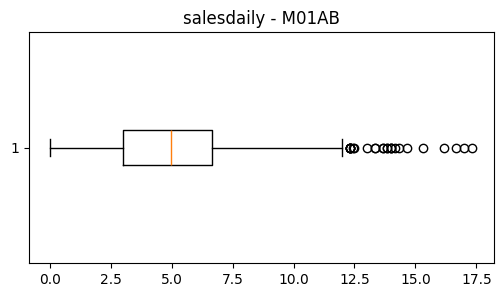

M01AE: 40 Ausreißer


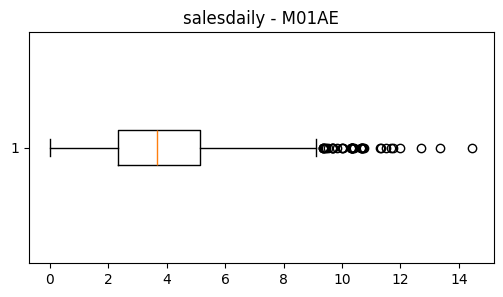

N02BA: 31 Ausreißer


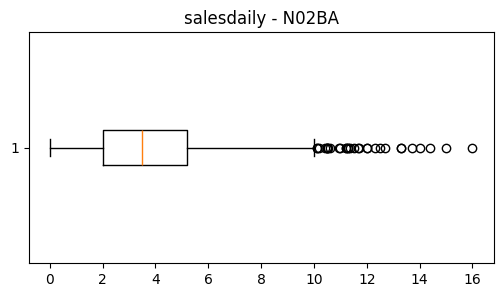

N02BE: 48 Ausreißer


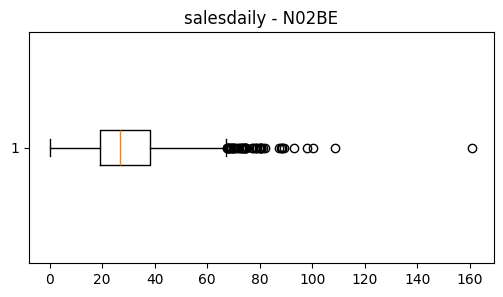

N05B: 48 Ausreißer


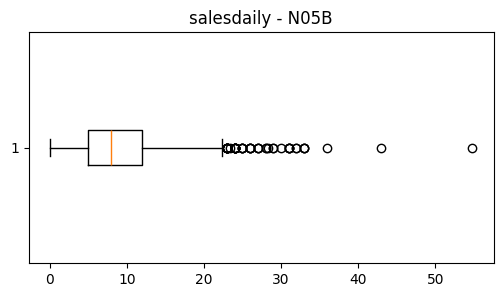

N05C: 160 Ausreißer


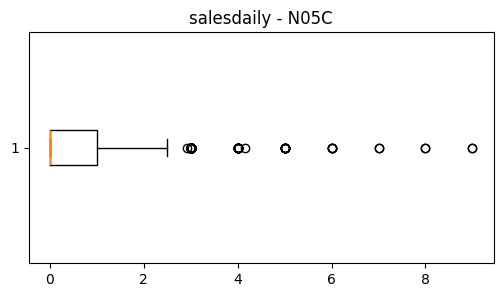

R03: 124 Ausreißer


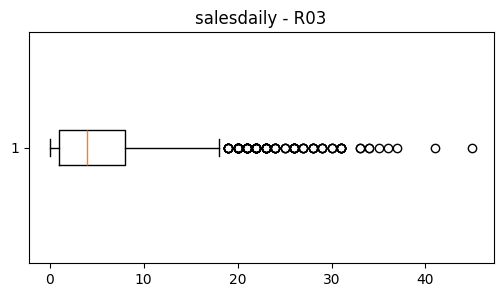

R06: 81 Ausreißer


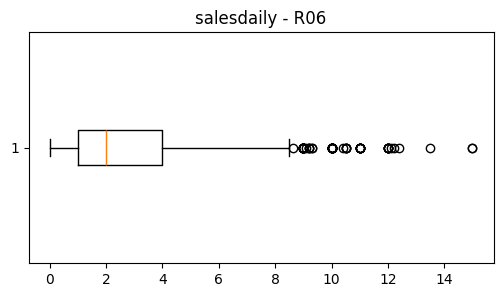

Year: 0 Ausreißer


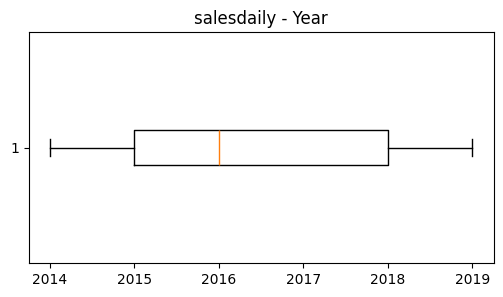

Month: 0 Ausreißer


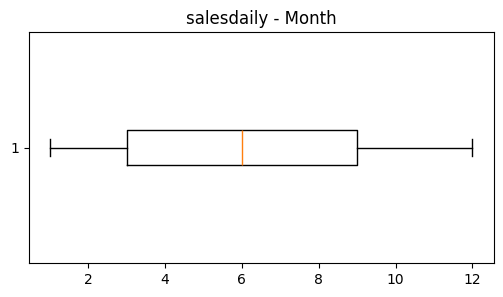

Hour: 2 Ausreißer


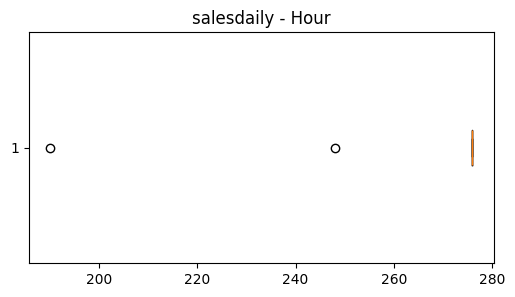


===== saleshourly =====
M01AB: 8899 Ausreißer


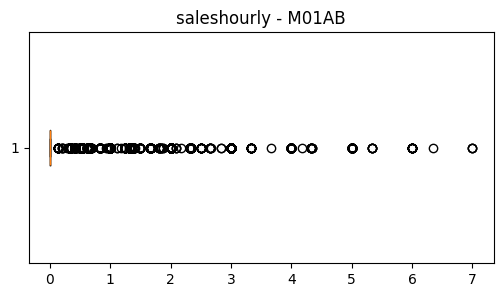

M01AE: 9515 Ausreißer


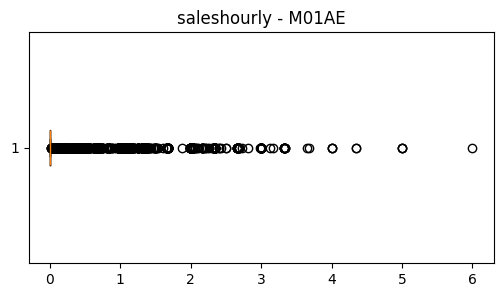

N02BA: 7446 Ausreißer


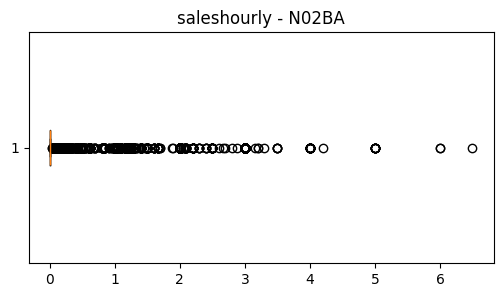

N02BE: 4189 Ausreißer


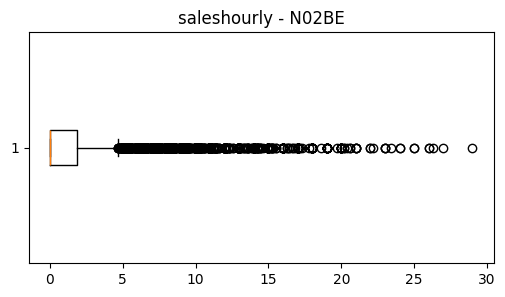

N05B: 10558 Ausreißer


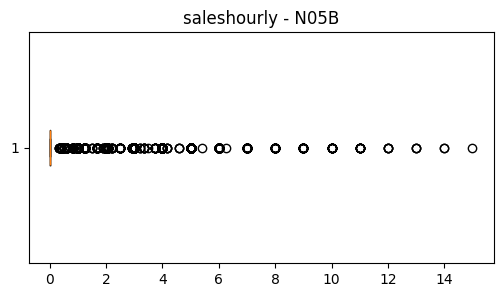

N05C: 864 Ausreißer


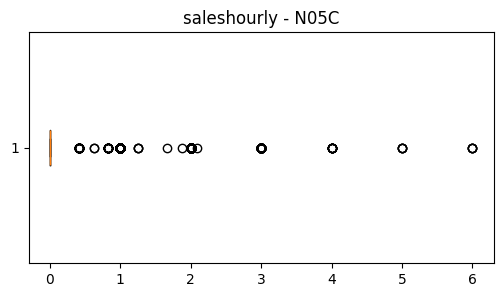

R03: 3412 Ausreißer


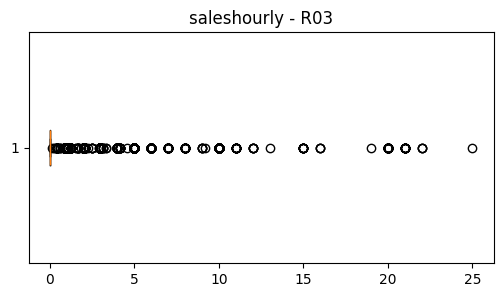

R06: 5285 Ausreißer


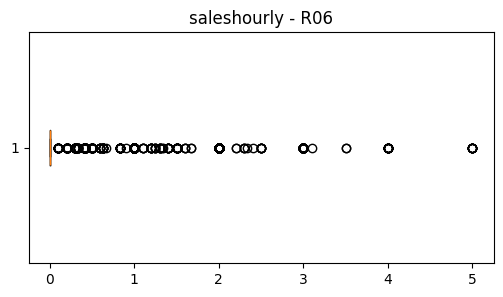

Year: 0 Ausreißer


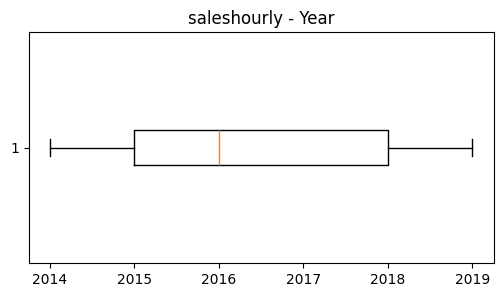

Month: 0 Ausreißer


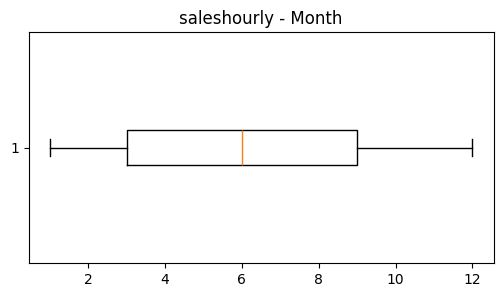

Hour: 0 Ausreißer


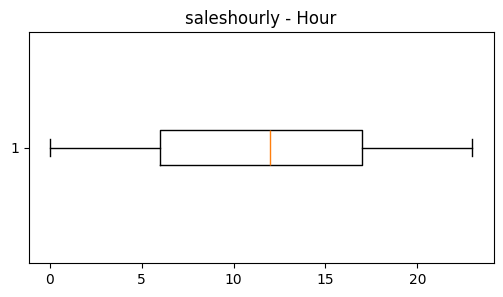


===== salesmonthly =====
M01AB: 2 Ausreißer


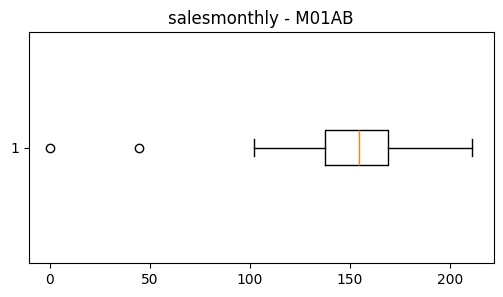

M01AE: 5 Ausreißer


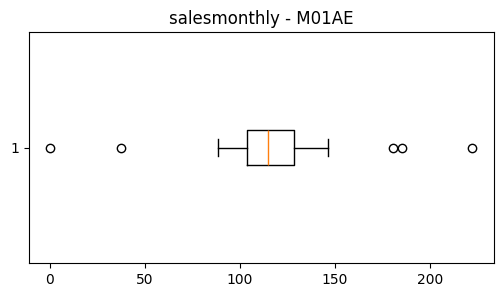

N02BA: 2 Ausreißer


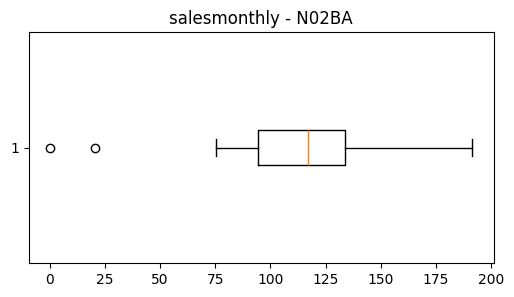

N02BE: 2 Ausreißer


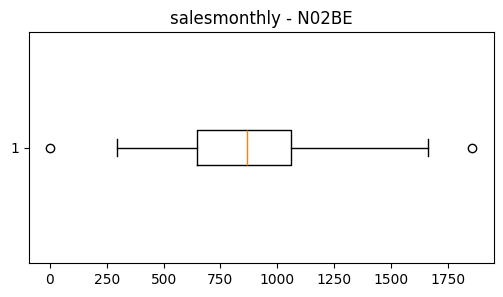

N05B: 8 Ausreißer


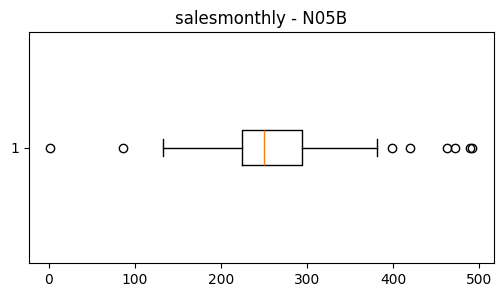

N05C: 2 Ausreißer


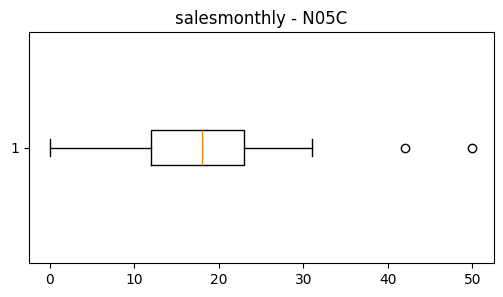

R03: 2 Ausreißer


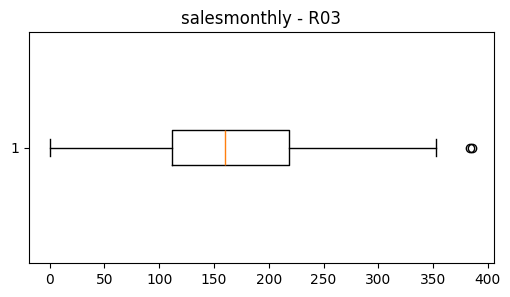

R06: 0 Ausreißer


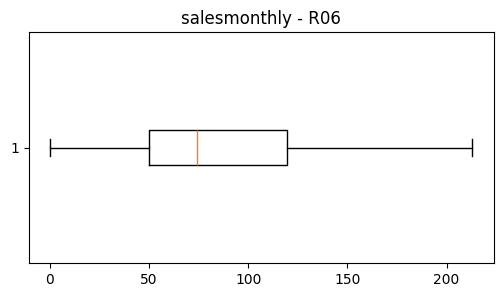


===== salesweekly =====
M01AB: 4 Ausreißer


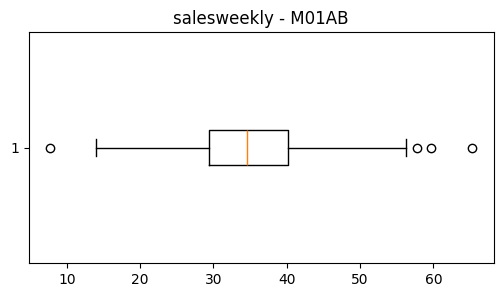

M01AE: 8 Ausreißer


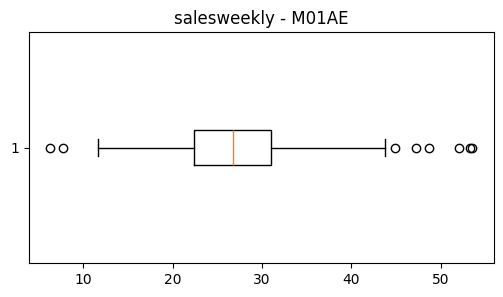

N02BA: 4 Ausreißer


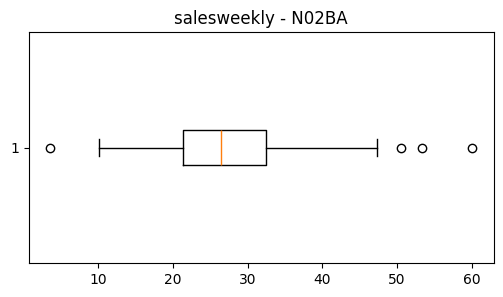

N02BE: 4 Ausreißer


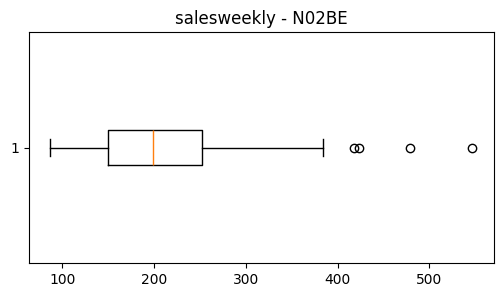

N05B: 17 Ausreißer


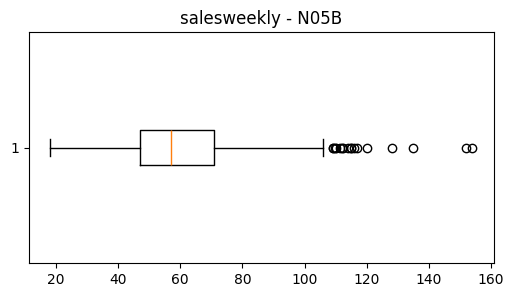

N05C: 6 Ausreißer


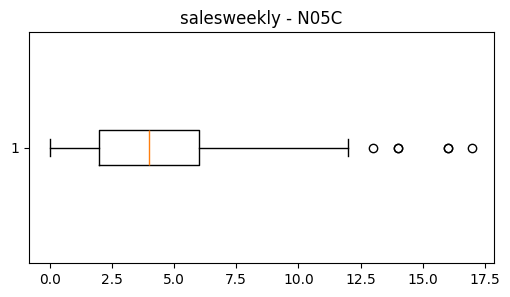

R03: 7 Ausreißer


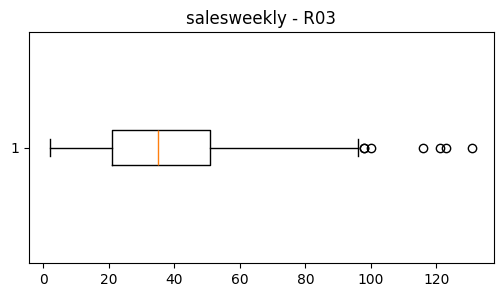

R06: 8 Ausreißer


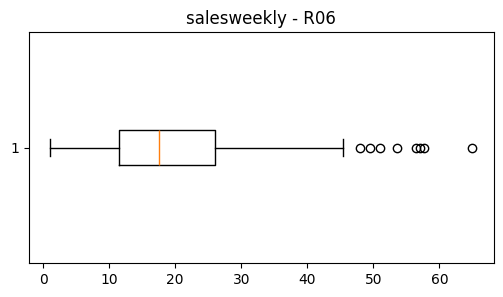

In [8]:
#search for outliers
for name, df in dfs.items():

    print(f"\n===== {name} =====")

    numeric_cols = df.select_dtypes(include="number").columns

    for col in numeric_cols:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]

        print(f"{col}: {len(outliers)} Ausreißer")

        plt.figure(figsize=(6,3))
        plt.boxplot(df[col], vert=False)
        plt.title(f"{name} - {col}")
        plt.show()

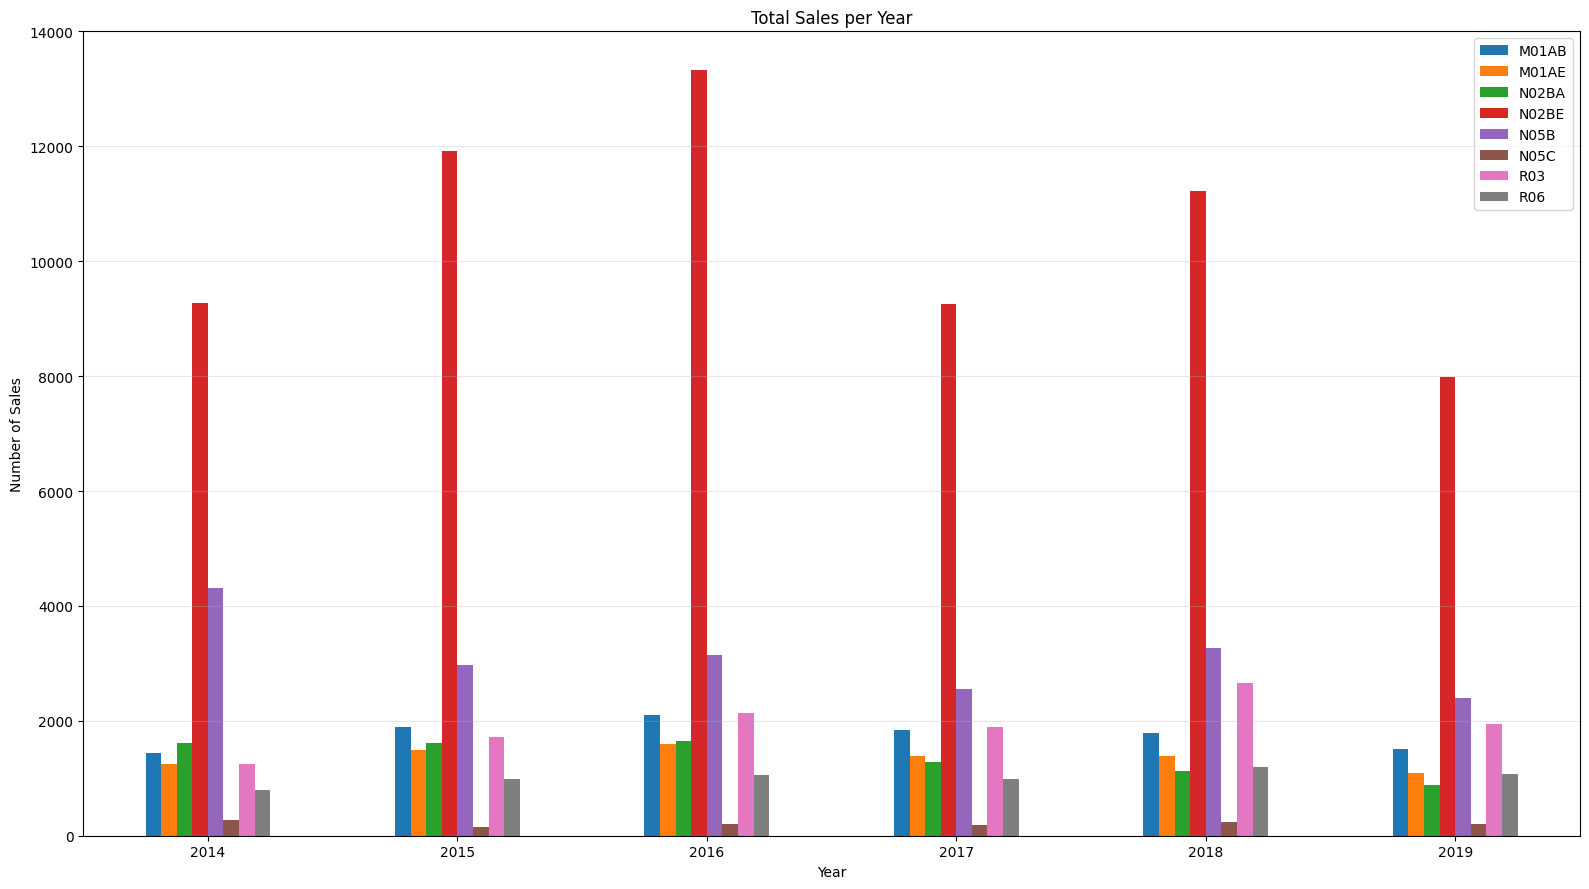

In [9]:
#Visualization of sales with years
medicine_cols = ["M01AB", "M01AE", "N02BA", "N02BE",
                 "N05B", "N05C", "R03", "R06"]
sales_per_year = df_salesdaily.groupby("Year")[medicine_cols
].sum()

fig, ax = plt.subplots(figsize=(16, 9))

sales_per_year.plot(kind="bar", ax=ax)

ax.set_title("Total Sales per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Sales")

ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

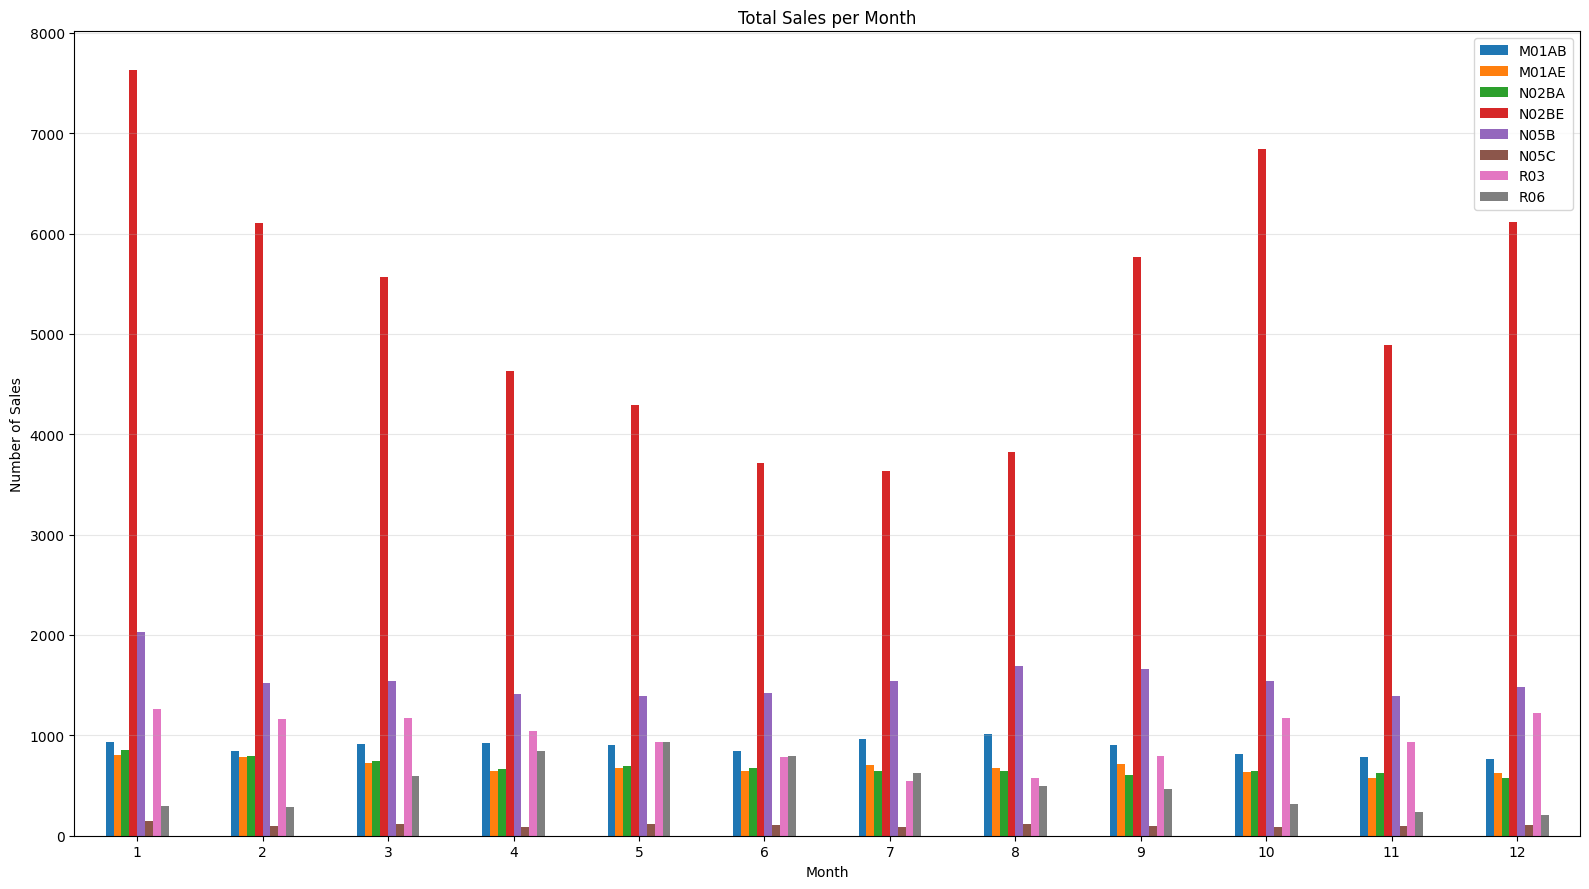

In [10]:
#Visualization of sales with months
sales_per_month = df_salesdaily.groupby("Month")[medicine_cols
].sum()

fig, ax = plt.subplots(figsize=(16, 9))

sales_per_month.plot(kind="bar", ax=ax)

ax.set_title("Total Sales per Month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Sales")

ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

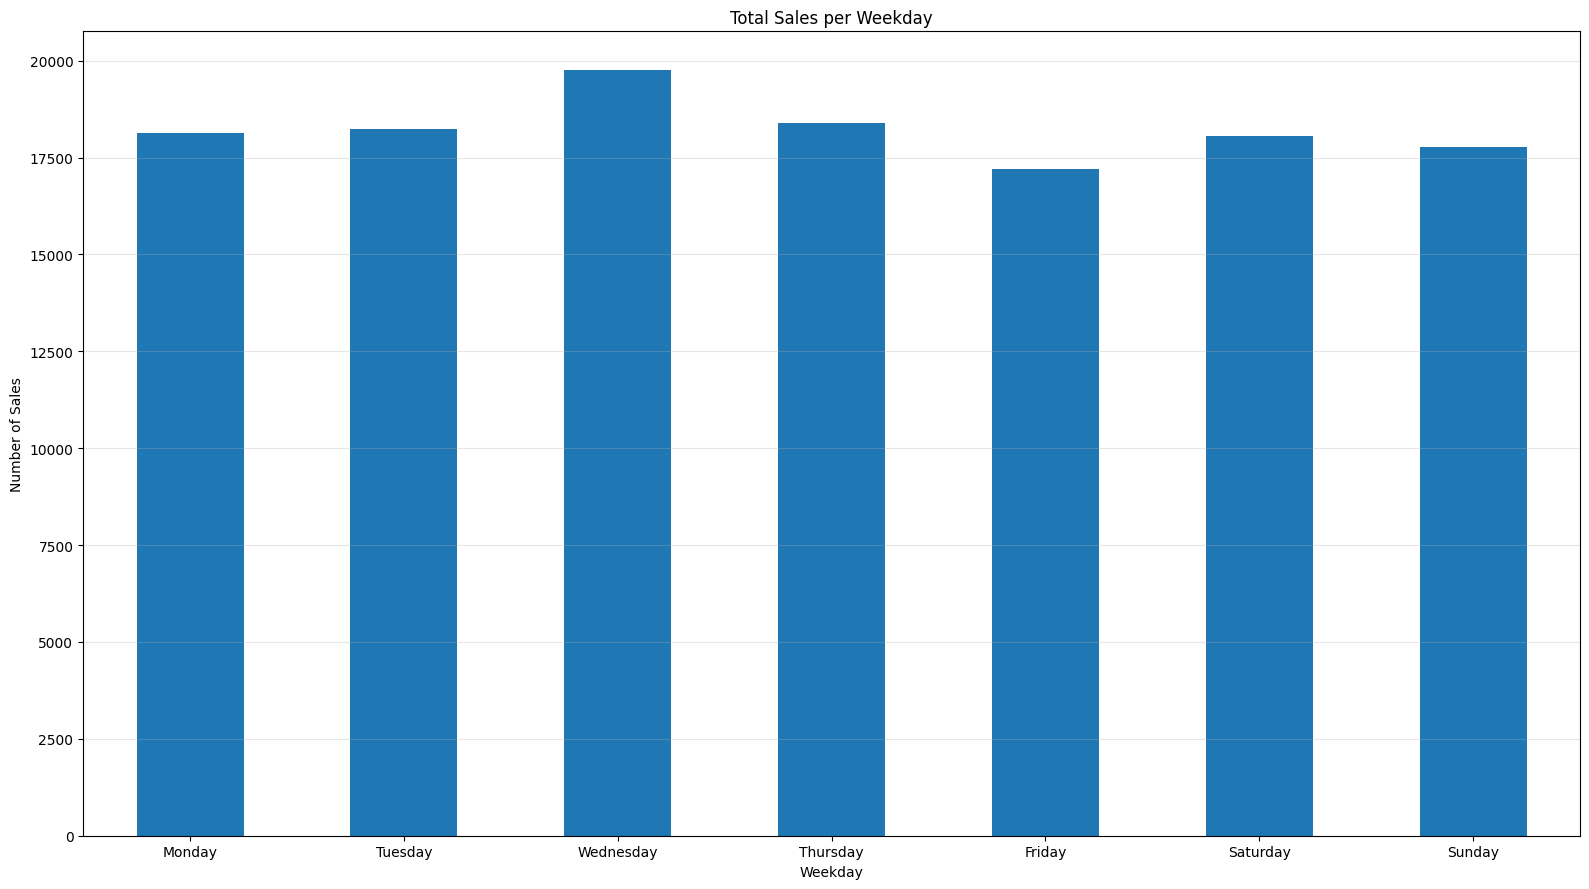

In [11]:
#Visualization of total sales with weekdays
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

total_sales_per_weekday = (df_salesdaily.groupby("Weekday Name")[medicine_cols].sum().sum(axis=1))

fig, ax = plt.subplots(figsize=(16, 9))

total_sales_per_weekday.plot(kind="bar", ax=ax)

ax.set_title("Total Sales per Weekday")
ax.set_xlabel("Weekday")
ax.set_ylabel("Number of Sales")

ax.set_xticklabels(weekday_order, rotation=0)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

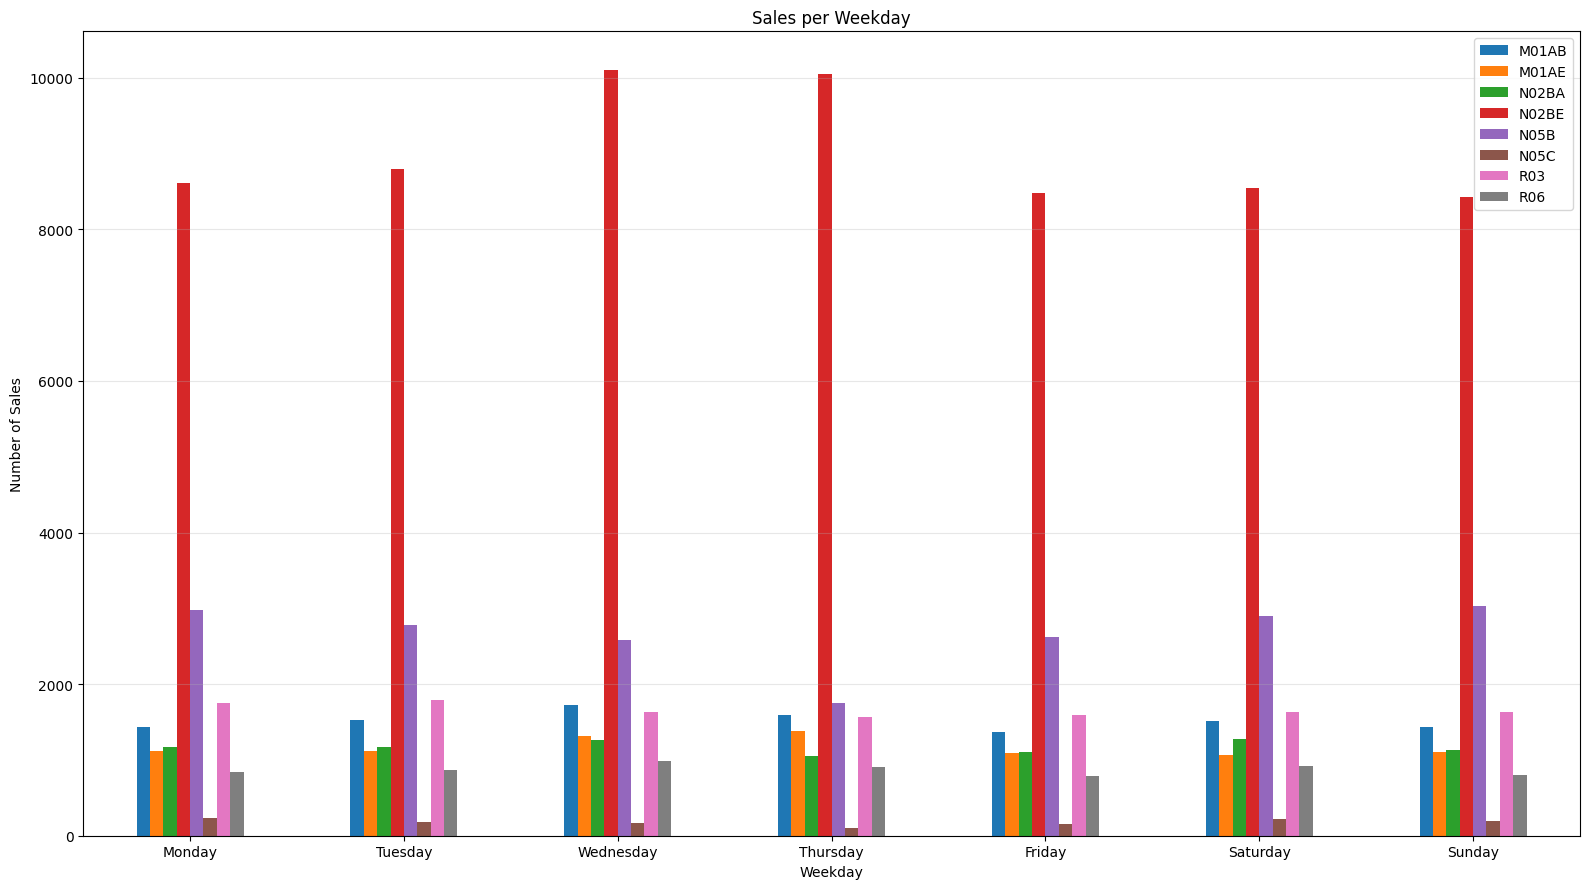

In [12]:
#Visualization of sales with weekdays
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

sales_per_weekday = (df_salesdaily.groupby("Weekday Name")[medicine_cols].sum())

fig, ax = plt.subplots(figsize=(16, 9))

sales_per_weekday.plot(kind="bar", ax=ax)

ax.set_title("Sales per Weekday")
ax.set_xlabel("Weekday")
ax.set_ylabel("Number of Sales")

ax.set_xticklabels(weekday_order, rotation=0)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

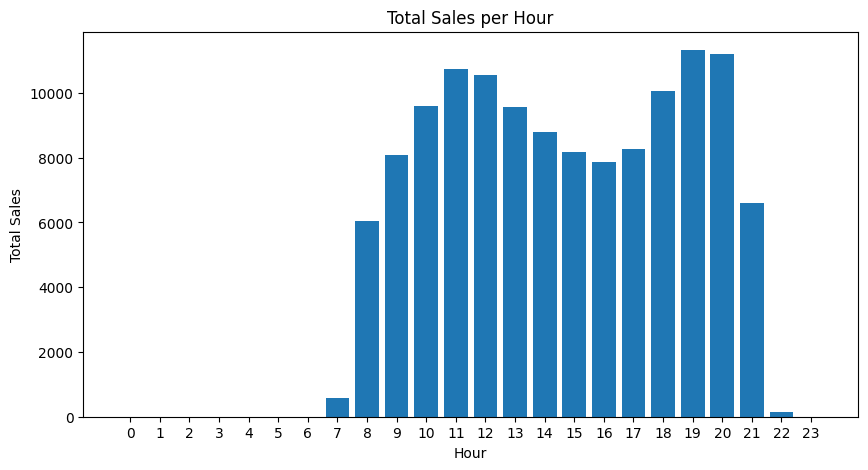

In [13]:
#total sales per hour
sales_per_hour = (
    df_saleshourly.groupby("Hour")[medicine_cols]
    .sum()
    .sum(axis=1)
)

plt.figure(figsize=(10,5))

plt.bar(sales_per_hour.index, sales_per_hour.values)

plt.title("Total Sales per Hour")
plt.xlabel("Hour")
plt.ylabel("Total Sales")
plt.xticks(range(24))

plt.show()

In [14]:
#total sales per hour within open times
sales_per_hour_open = (df_saleshourly_selected.groupby("Hour")[medicine_cols]
    .sum().sum(axis=1)
)

plt.figure(figsize=(10,5))

plt.bar(sales_per_hour_open.index, sales_per_hour_open.values)

plt.title("Total Sales per Hour within The Open Time")
plt.xlabel("Hour")
plt.ylabel("Total Sales")
plt.xticks(range(7, 23))

plt.show()

NameError: name 'df_saleshourly_selected' is not defined

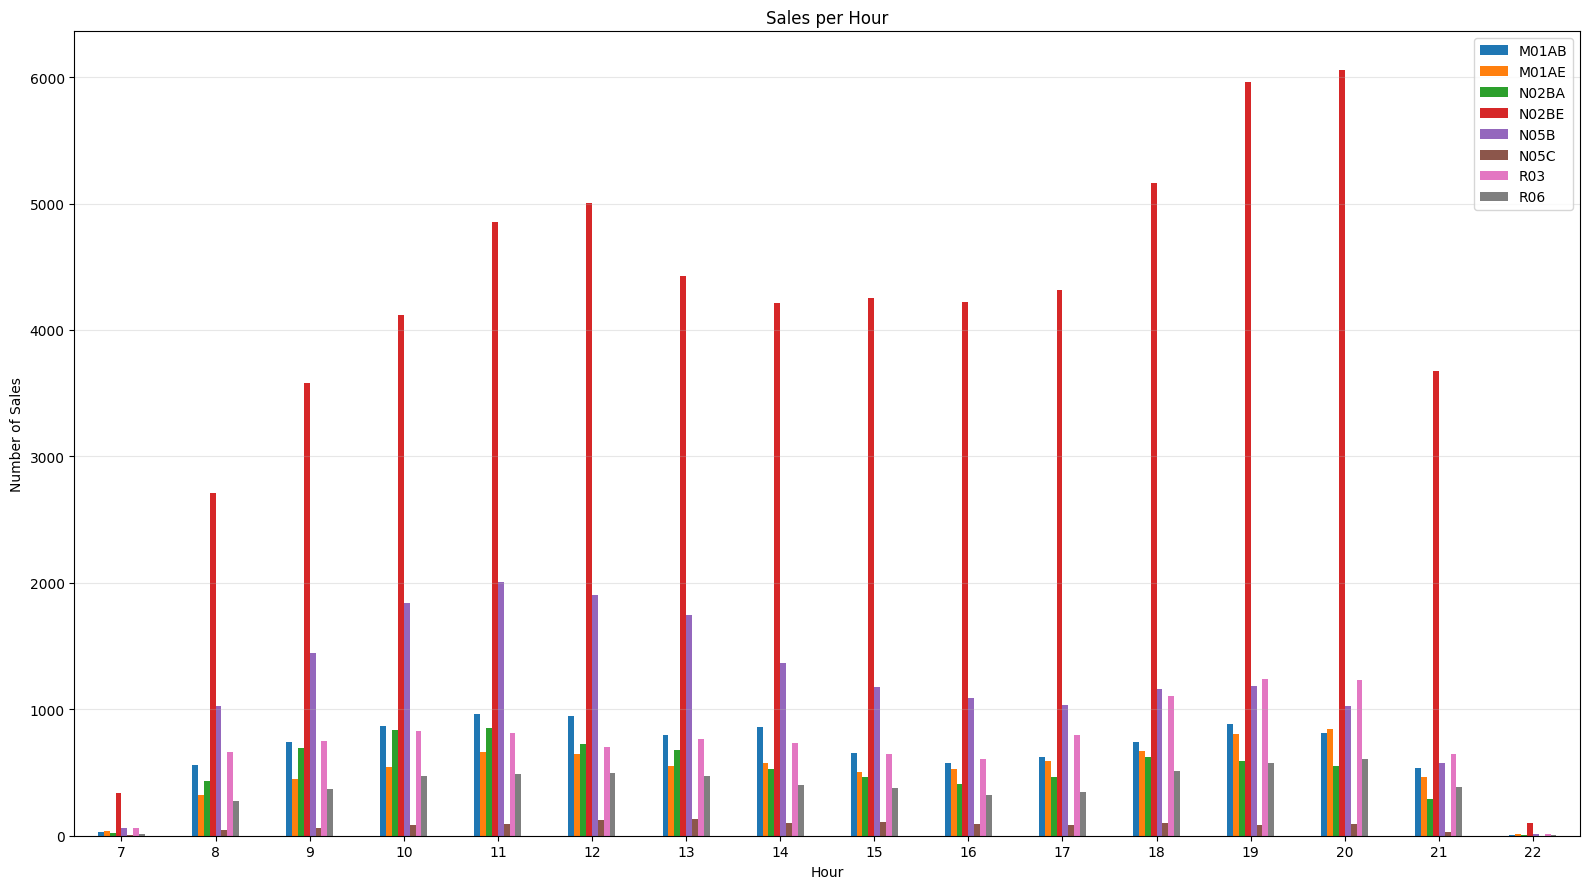

In [ ]:

df_saleshourly_selected = df_saleshourly[(df_saleshourly["Hour"] >= 7) & (df_saleshourly["Hour"] <= 22)]
sales_per_hour = df_saleshourly_selected.groupby("Hour")[medicine_cols
].sum()

fig, ax = plt.subplots(figsize=(16, 9))

sales_per_hour.plot(kind="bar", ax=ax)

ax.set_title("Sales per Hour")
ax.set_xlabel("Hour")
ax.set_ylabel("Number of Sales")

ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


===== salesdaily =====


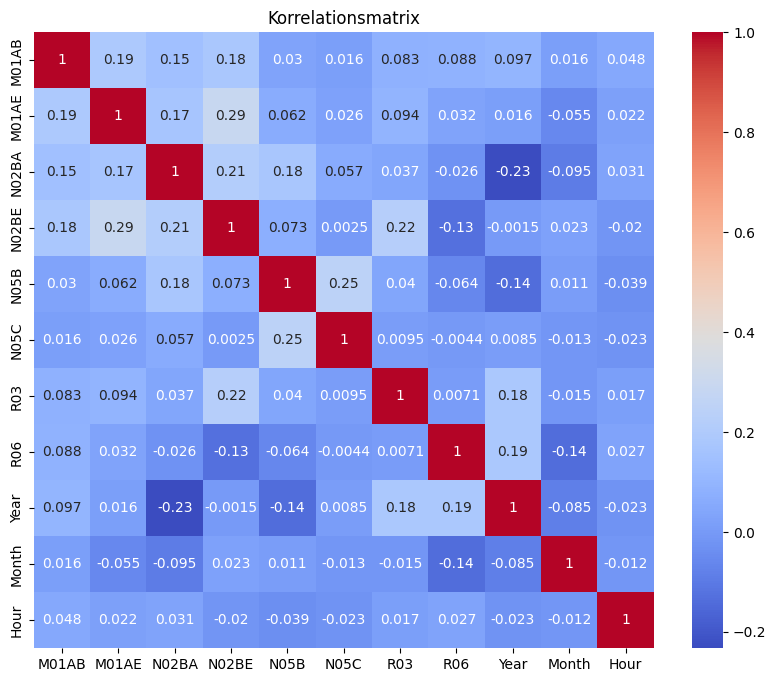


===== saleshourly =====


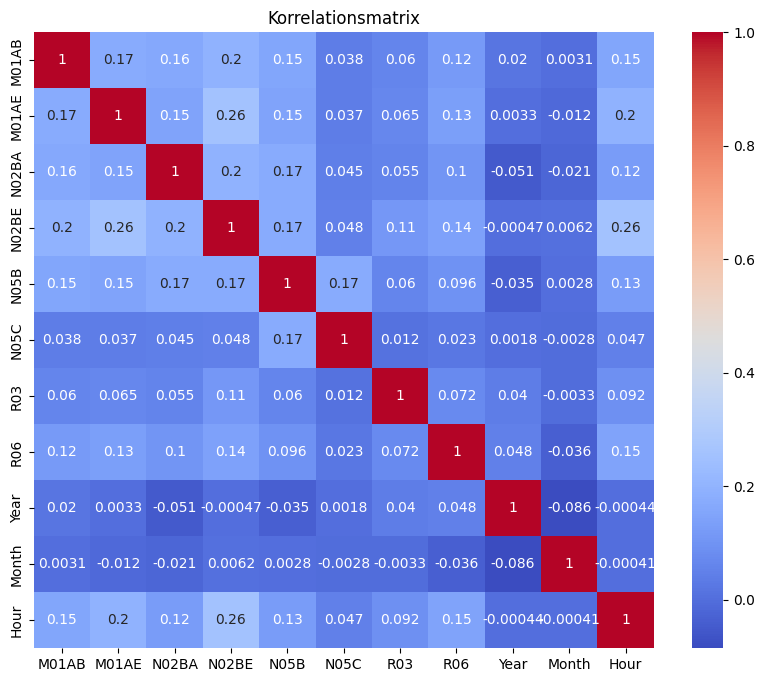


===== salesmonthly =====


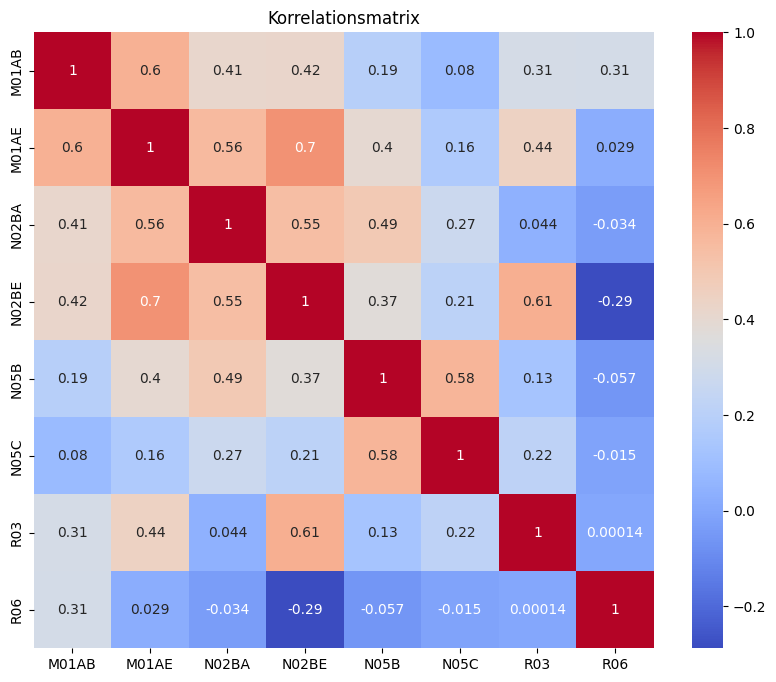


===== salesweekly =====


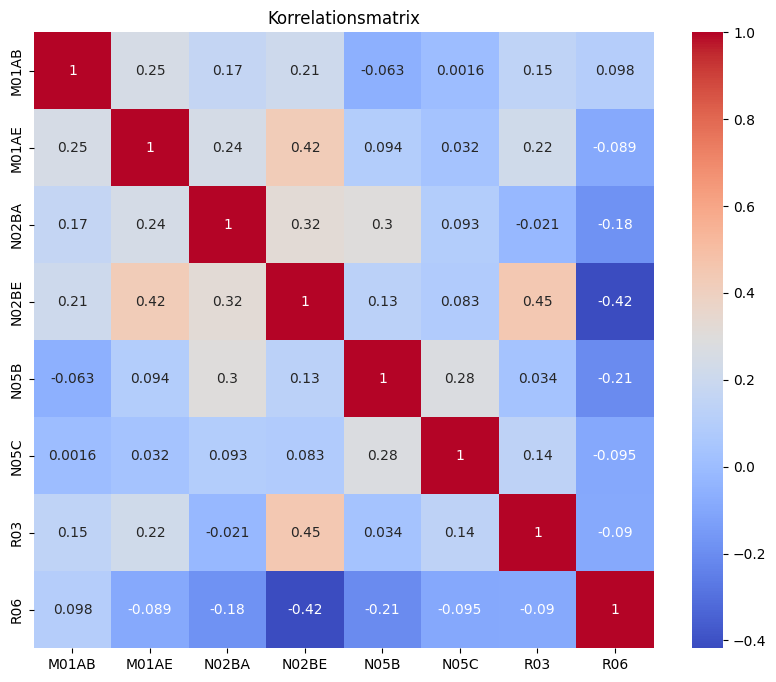

In [ ]:
for name, df in dfs.items():

    print(f"\n===== {name} =====")
    
    plt.figure(figsize=(10,8))
    sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
    plt.title("Korrelationsmatrix")
    plt.show()

In [16]:
#Lineare Regression för korrelation ab 0.2 bei salesdaily tabelle
# Nur numerische Spalten
corr = df_salesdaily.corr(numeric_only=True)

# Nur obere Dreiecksmatrix betrachten
corr_upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Korrelationen >= 0.2
threshold = 0.2

pairs = []

for row in corr_upper.index:
    for col in corr_upper.columns:
        value = corr_upper.loc[row, col]
        if pd.notna(value) and abs(value) >= threshold:
            pairs.append((row, col, value))

for row, col, value in pairs:
    print(f"{row} - {col}: {value:.2f}")


M01AE - N02BE: 0.29
N02BA - N02BE: 0.21
N02BA - Year: -0.23
N02BE - R03: 0.22
N05B - N05C: 0.25


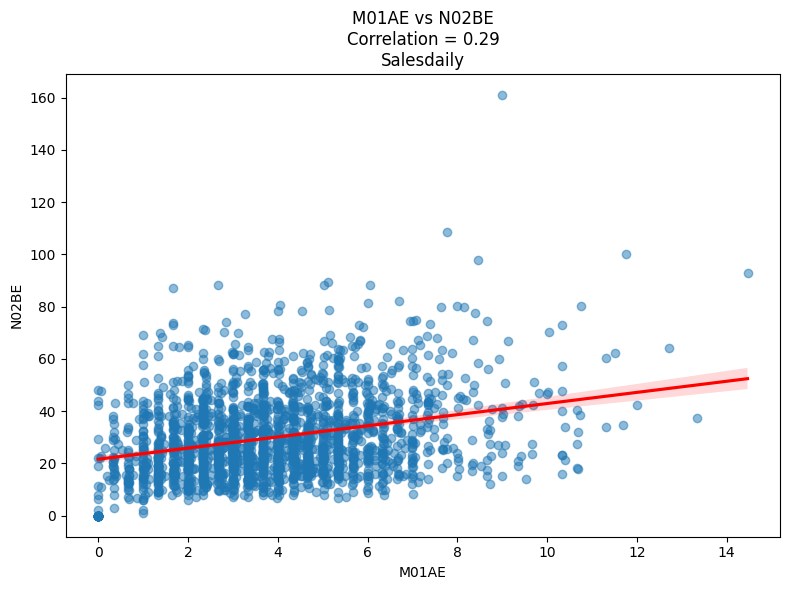

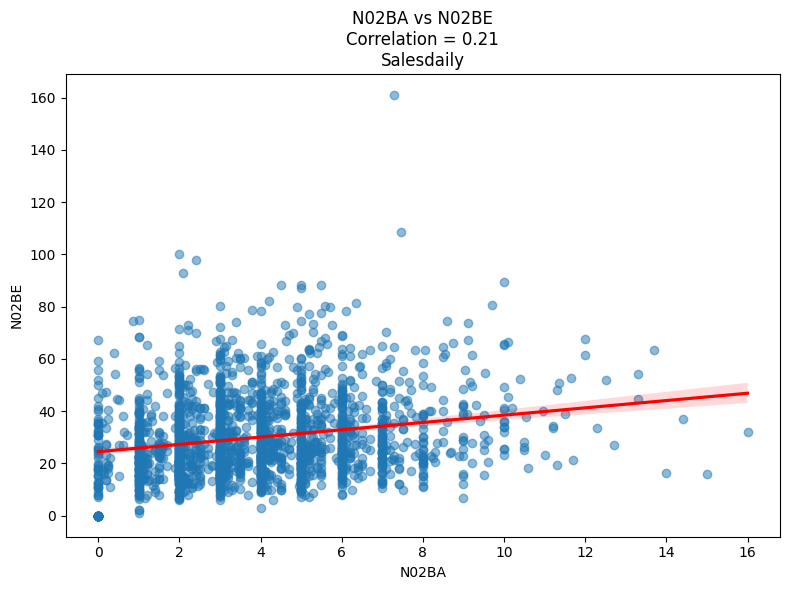

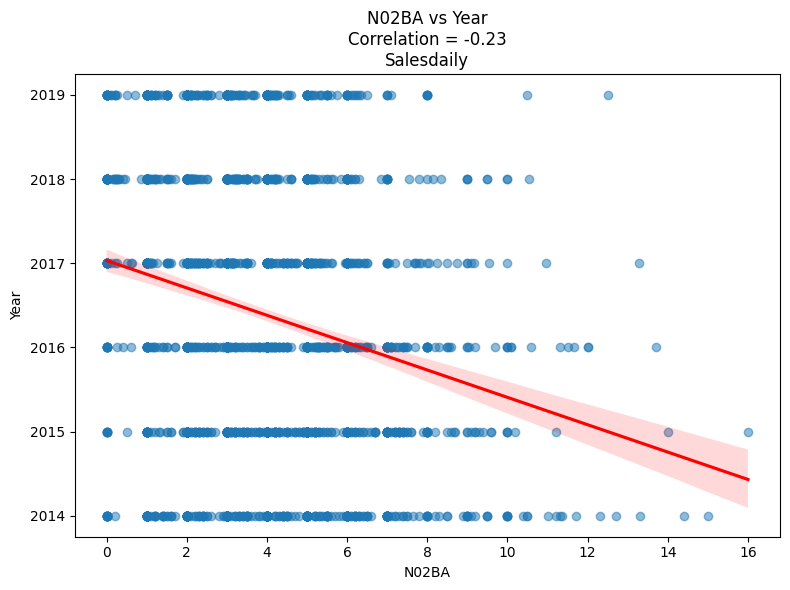

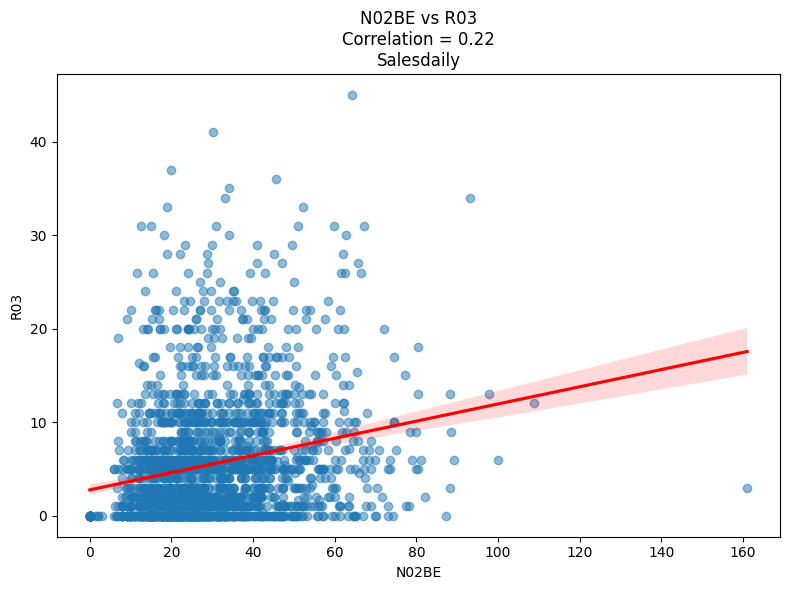

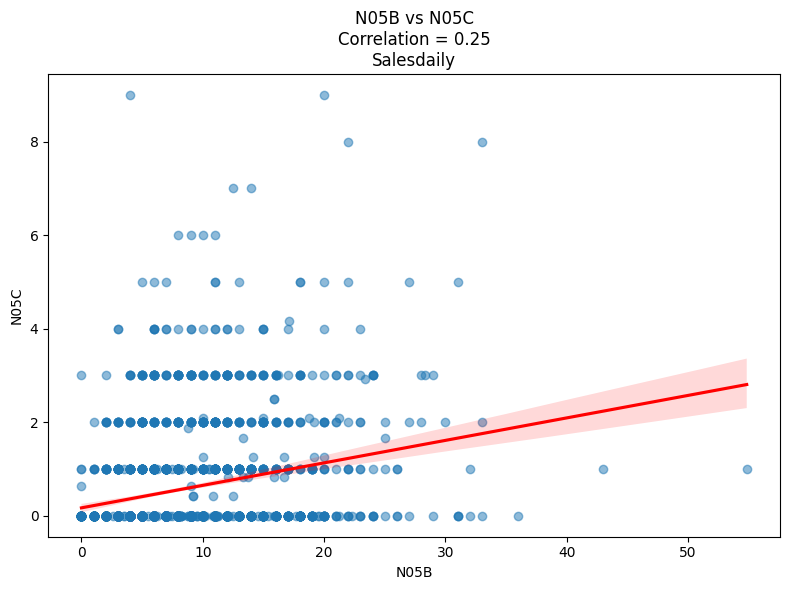

In [17]:
#Lineare Regression för korrelation ab 0.2 bei salesdaily tabelle
for x, y, corr_value in pairs:
    fig, ax = plt.subplots(figsize=(8,6))

    sns.regplot(
        data=df_salesdaily,
        x=x,
        y=y,
        scatter_kws={"alpha":0.5},
        line_kws={"color":"red"},
        ax=ax
    )

    ax.set_title(f"{x} vs {y}\nCorrelation = {corr_value:.2f}\nSalesdaily")

    plt.tight_layout()
    plt.show()

In [18]:
#Lineare Regression för korrelation ab 0.2 bei saleshourly tabelle
# Nur numerische Spalten
corr = df_saleshourly.corr(numeric_only=True)

# Nur obere Dreiecksmatrix betrachten
corr_upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Korrelationen >= 0.2
threshold = 0.2

pairs = []

for row in corr_upper.index:
    for col in corr_upper.columns:
        value = corr_upper.loc[row, col]
        if pd.notna(value) and abs(value) >= threshold:
            pairs.append((row, col, value))

for row, col, value in pairs:
    print(f"{row} - {col}: {value:.2f}")


M01AE - N02BE: 0.26
N02BE - Hour: 0.26


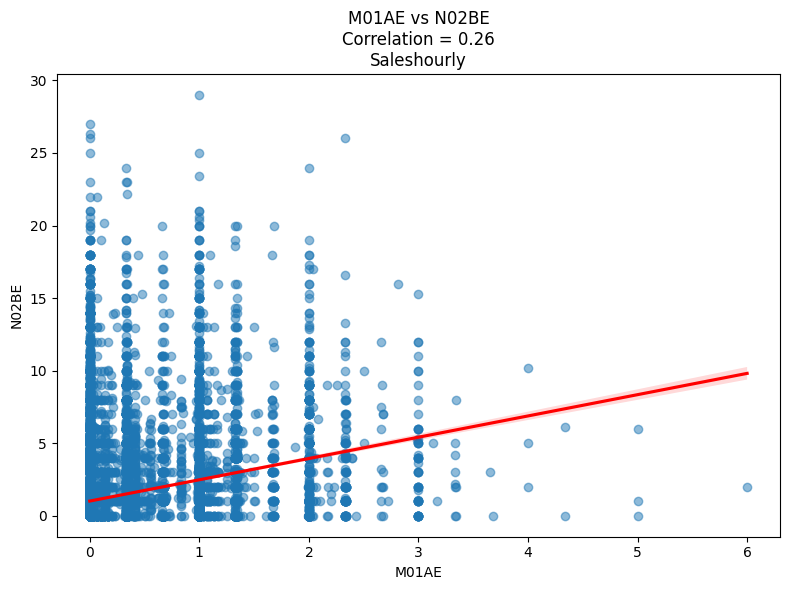

In [19]:
#Lineare Regression för korrelation ab 0.2 bei saleshourly tabelle

fig, ax = plt.subplots(figsize=(8,6))

sns.regplot(data=df_saleshourly,
        x='M01AE',
        y='N02BE',
        scatter_kws={"alpha":0.5},
        line_kws={"color":"red"},
        ax=ax
    )

ax.set_title("M01AE vs N02BE\nCorrelation = 0.26\nSaleshourly")
plt.tight_layout()
plt.show()

In [22]:
#Lineare Regression för korrelation ab 0.2 bei salesmonthly tabelle
# Nur numerische Spalten
corr = df_salesmonthly.corr(numeric_only=True)

# Nur obere Dreiecksmatrix betrachten
corr_upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Korrelationen >= 0.2
threshold = 0.2

pairs = []

for row in corr_upper.index:
    for col in corr_upper.columns:
        value = corr_upper.loc[row, col]
        if pd.notna(value) and abs(value) >= threshold:
            pairs.append((row, col, value))

for row, col, value in pairs:
    print(f"{row} - {col}: {value:.2f}")


M01AB - M01AE: 0.60
M01AB - N02BA: 0.41
M01AB - N02BE: 0.42
M01AB - R03: 0.31
M01AB - R06: 0.31
M01AE - N02BA: 0.56
M01AE - N02BE: 0.70
M01AE - N05B: 0.40
M01AE - R03: 0.44
N02BA - N02BE: 0.55
N02BA - N05B: 0.49
N02BA - N05C: 0.27
N02BE - N05B: 0.37
N02BE - N05C: 0.21
N02BE - R03: 0.61
N02BE - R06: -0.29
N05B - N05C: 0.58
N05C - R03: 0.22


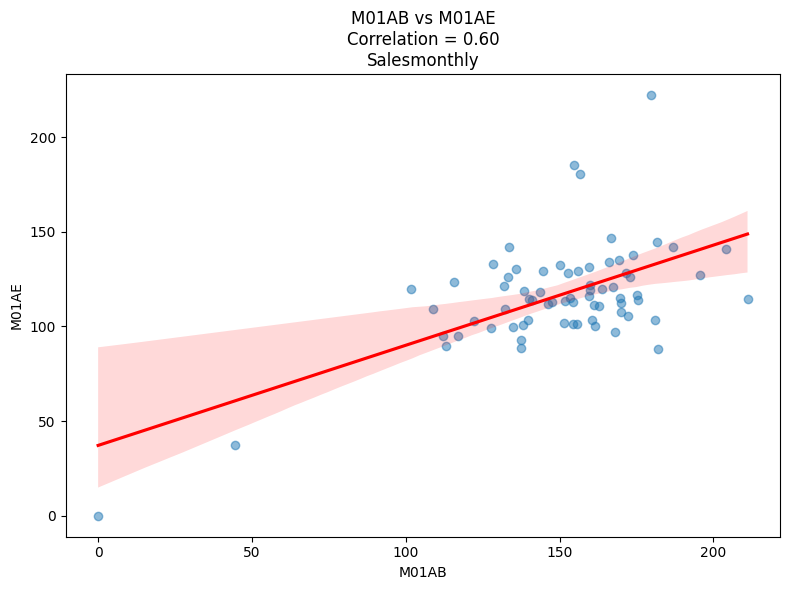

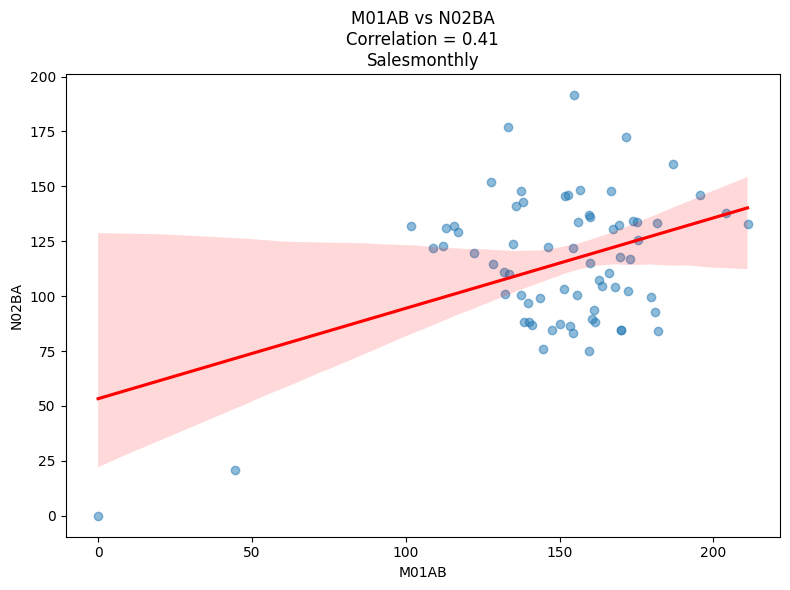

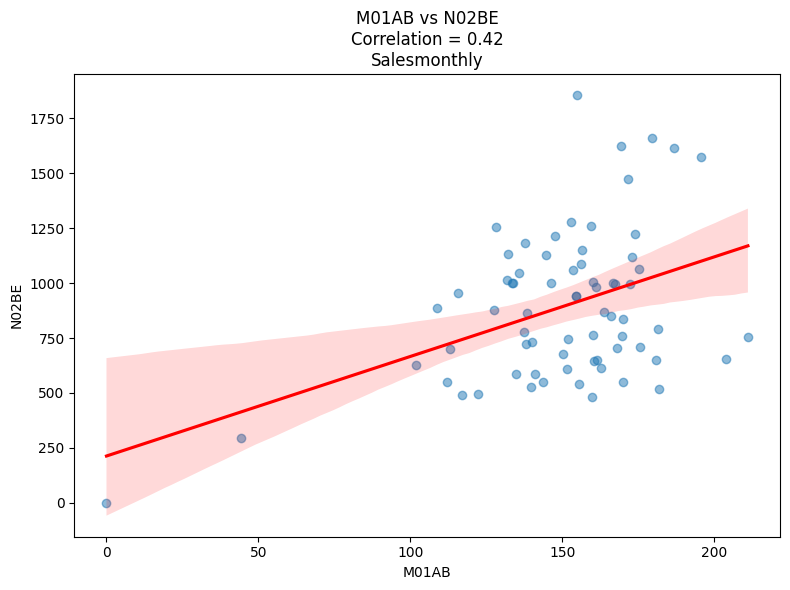

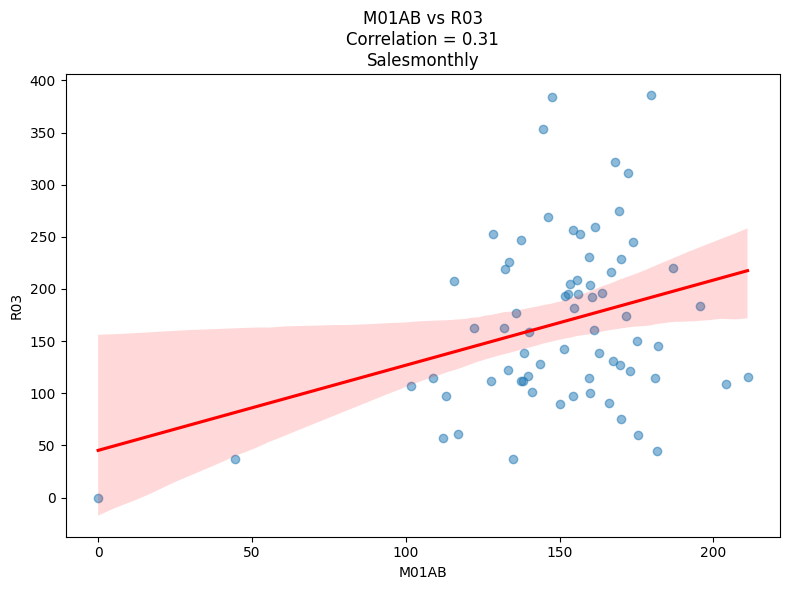

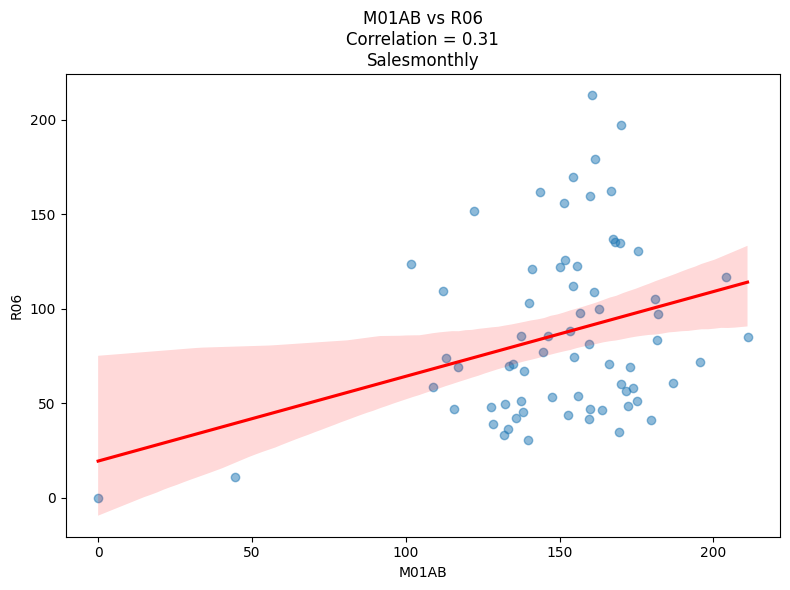

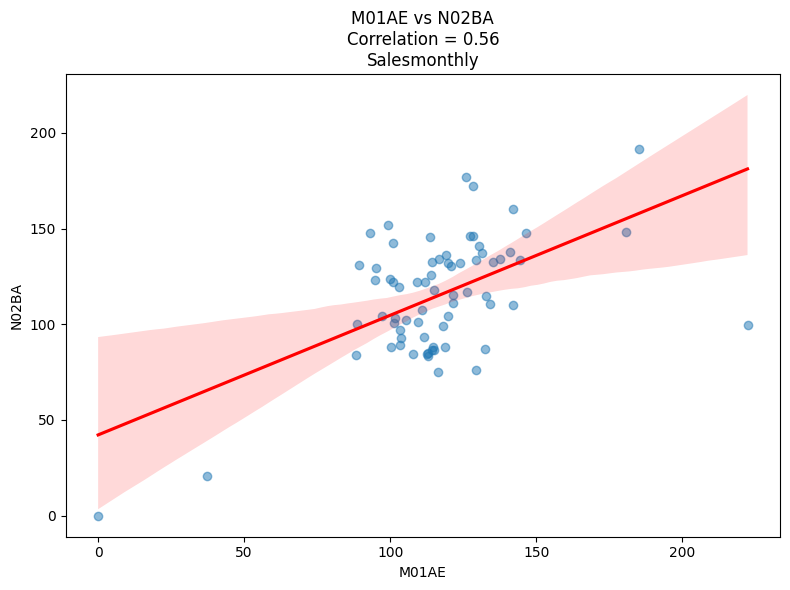

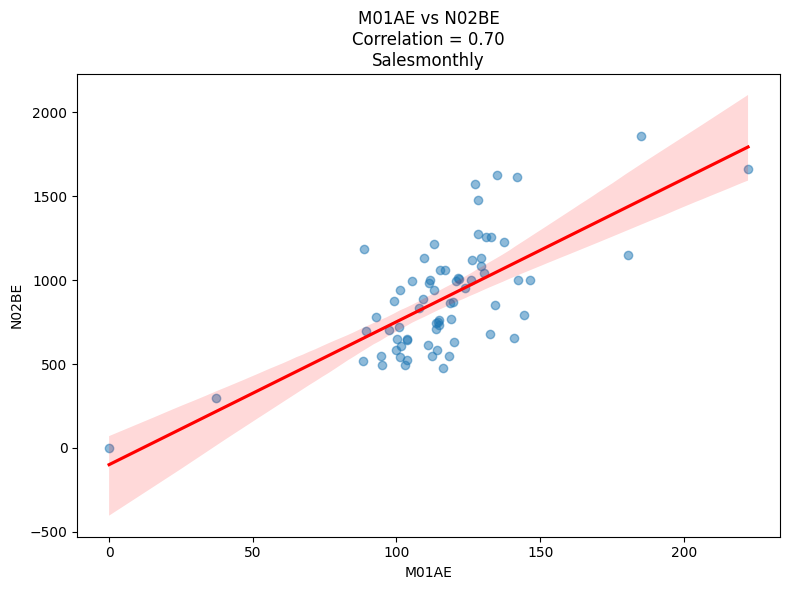

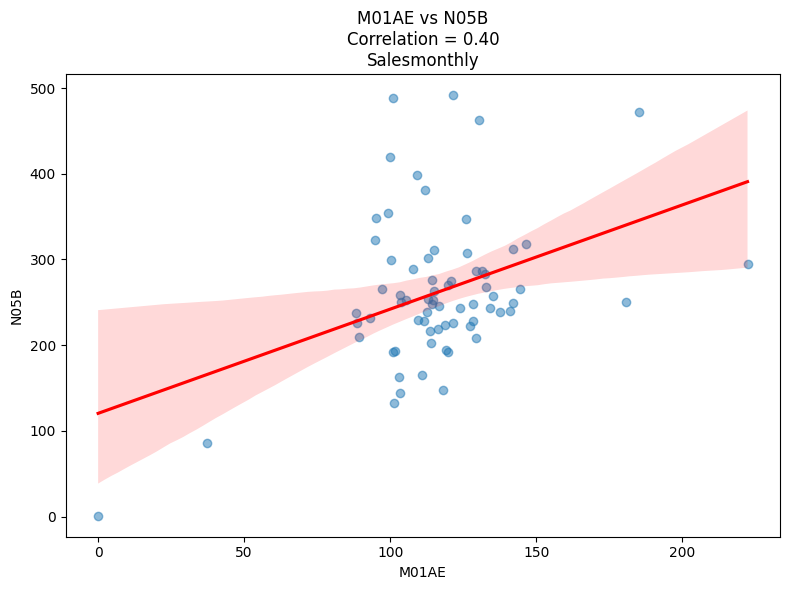

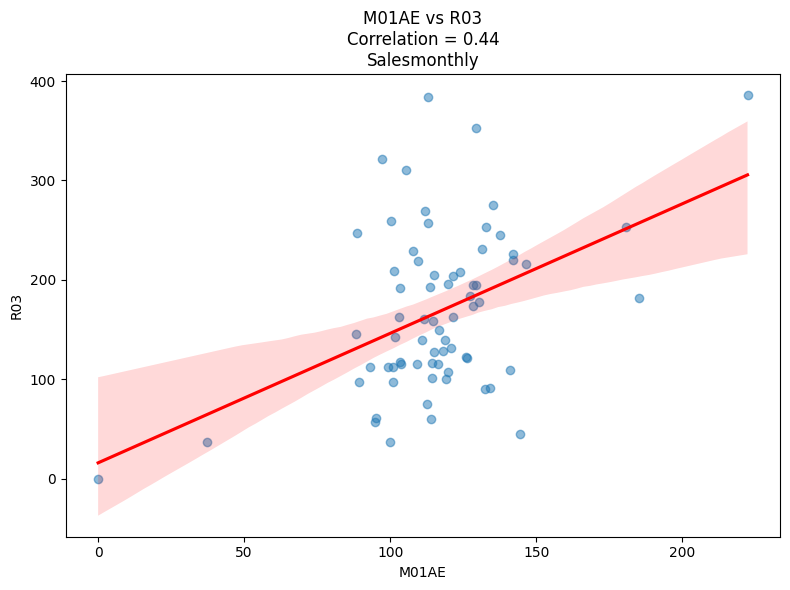

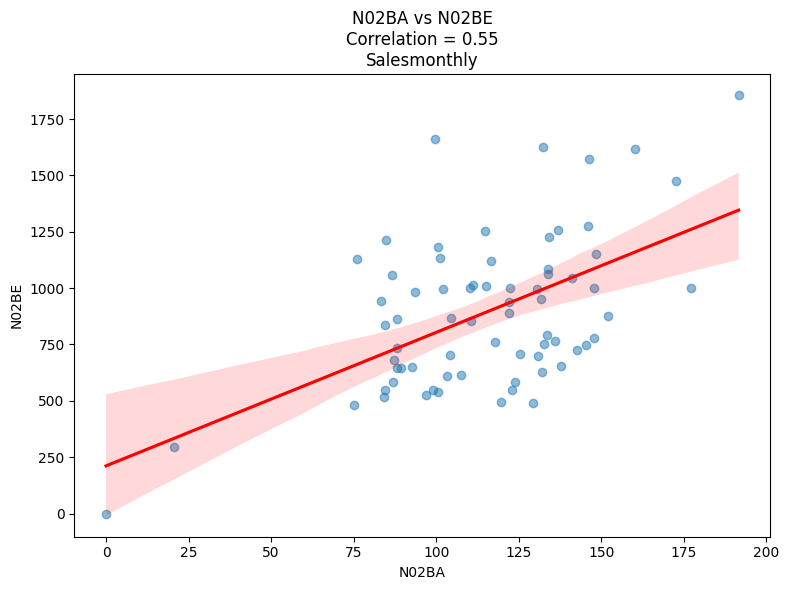

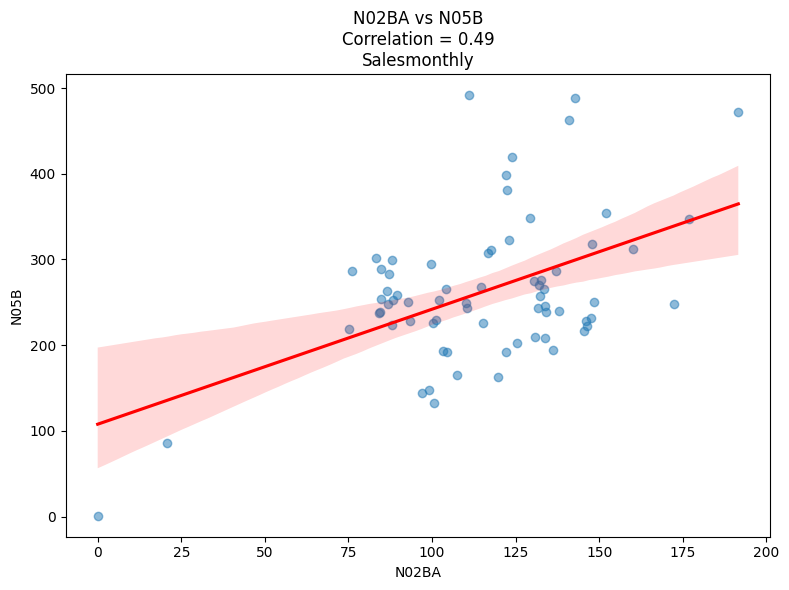

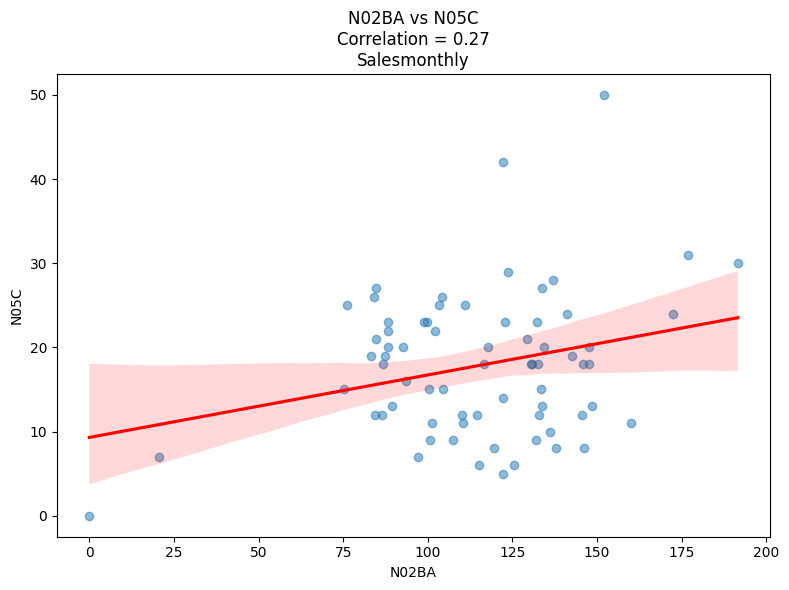

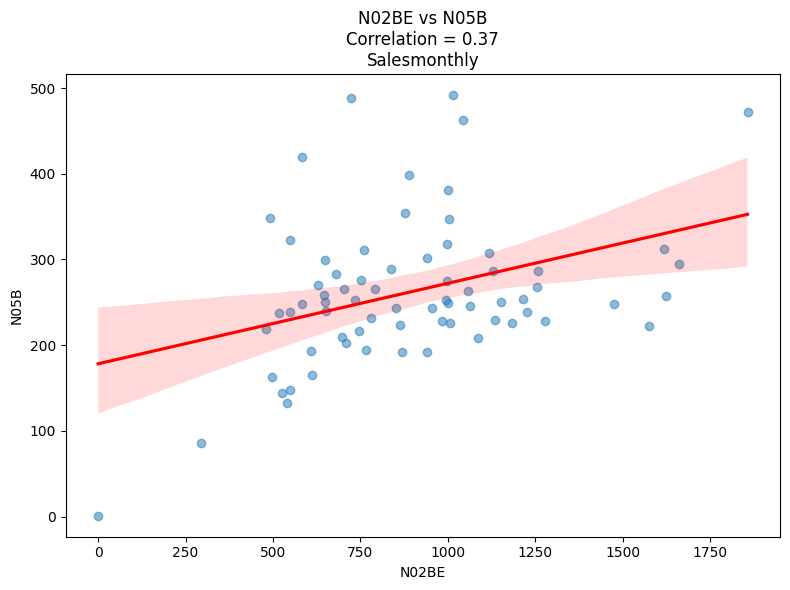

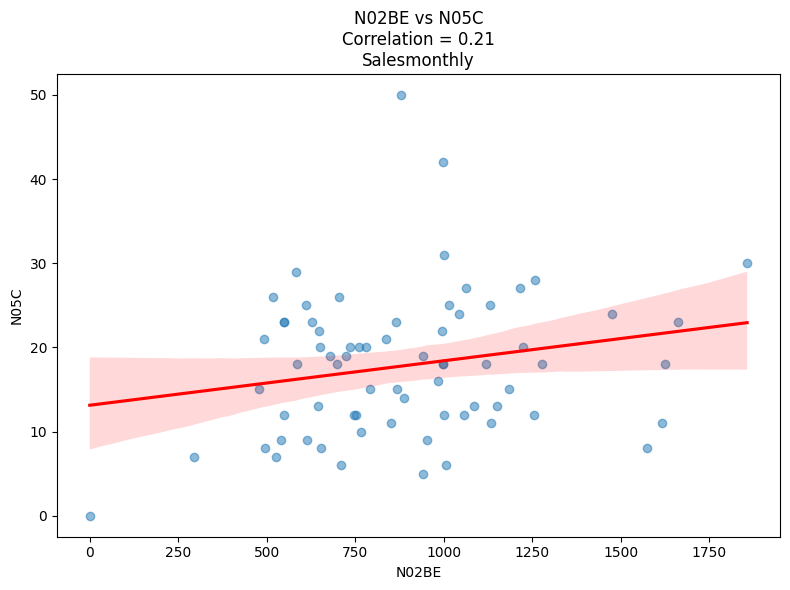

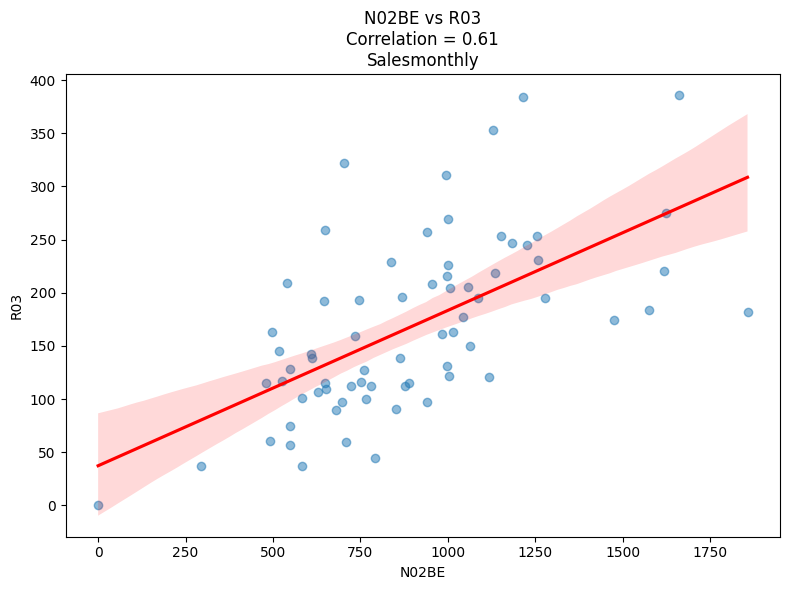

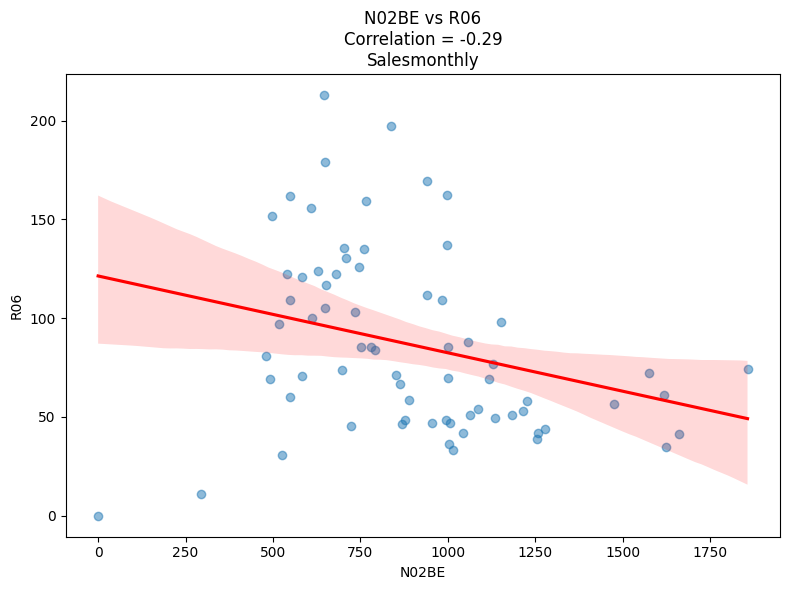

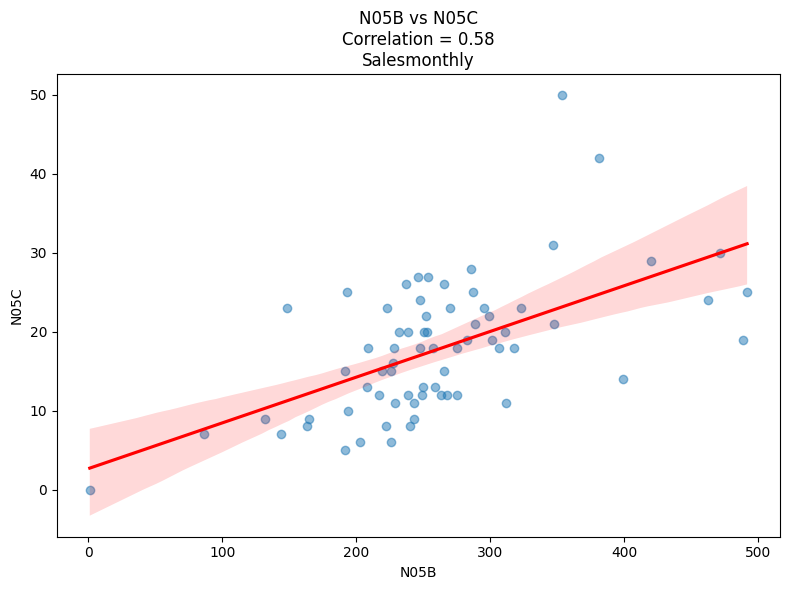

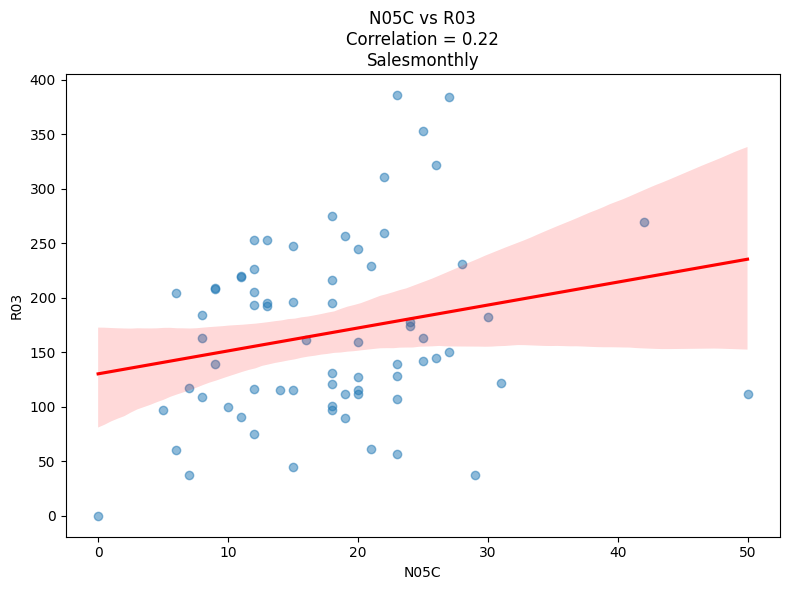

In [24]:
#Lineare Regression för korrelation ab 0.2 bei salesmonthly tabelle
for x, y, corr_value in pairs:
    fig, ax = plt.subplots(figsize=(8,6))

    sns.regplot(
        data=df_salesmonthly,
        x=x,
        y=y,
        scatter_kws={"alpha":0.5},
        line_kws={"color":"red"},
        ax=ax
    )

    ax.set_title(f"{x} vs {y}\nCorrelation = {corr_value:.2f}\nSalesmonthly")

    plt.tight_layout()
    plt.show()

In [25]:
#Lineare Regression för korrelation ab 0.2 bei salesweekly tabelle
# Nur numerische Spalten
corr = df_salesmonthly.corr(numeric_only=True)

# Nur obere Dreiecksmatrix betrachten
corr_upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Korrelationen >= 0.2
threshold = 0.2

pairs = []

for row in corr_upper.index:
    for col in corr_upper.columns:
        value = corr_upper.loc[row, col]
        if pd.notna(value) and abs(value) >= threshold:
            pairs.append((row, col, value))

for row, col, value in pairs:
    print(f"{row} - {col}: {value:.2f}")


M01AB - M01AE: 0.60
M01AB - N02BA: 0.41
M01AB - N02BE: 0.42
M01AB - R03: 0.31
M01AB - R06: 0.31
M01AE - N02BA: 0.56
M01AE - N02BE: 0.70
M01AE - N05B: 0.40
M01AE - R03: 0.44
N02BA - N02BE: 0.55
N02BA - N05B: 0.49
N02BA - N05C: 0.27
N02BE - N05B: 0.37
N02BE - N05C: 0.21
N02BE - R03: 0.61
N02BE - R06: -0.29
N05B - N05C: 0.58
N05C - R03: 0.22


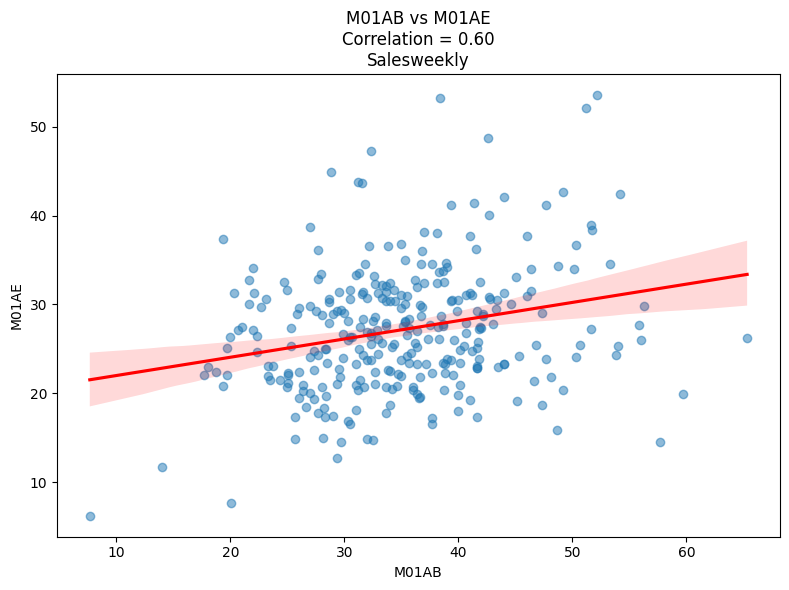

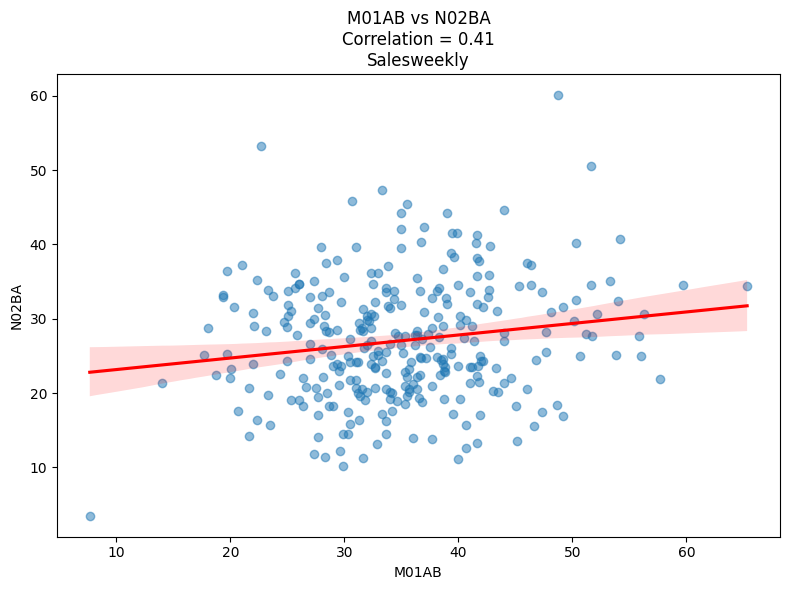

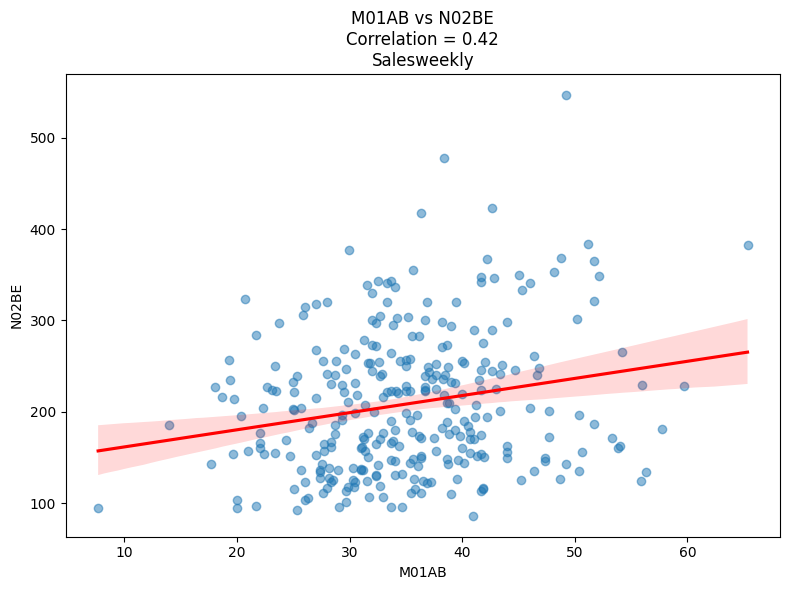

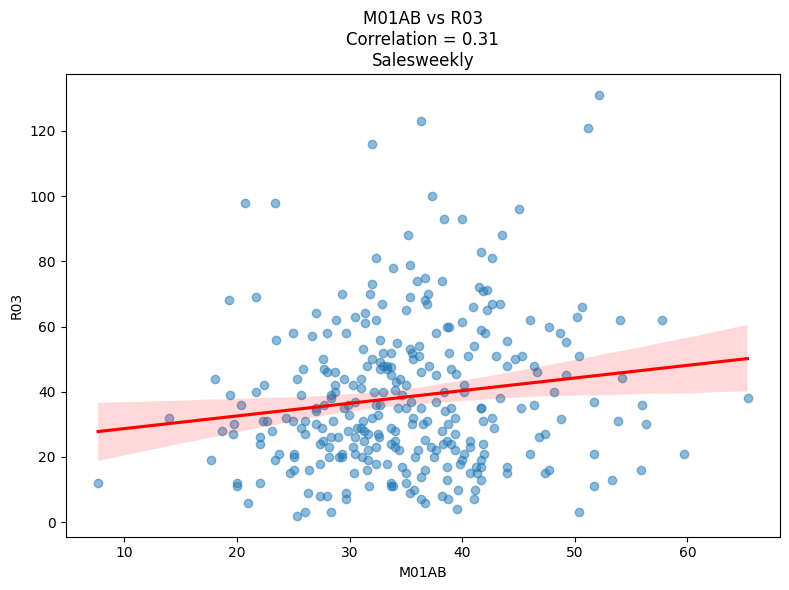

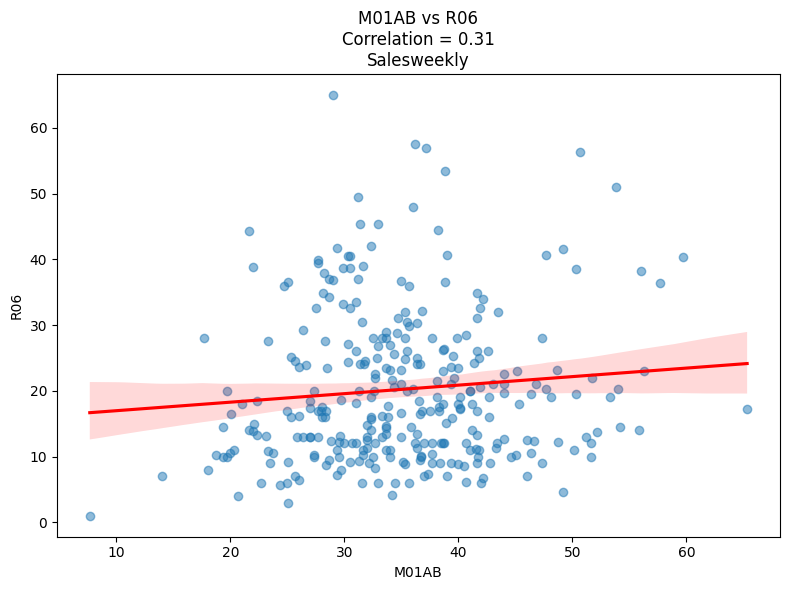

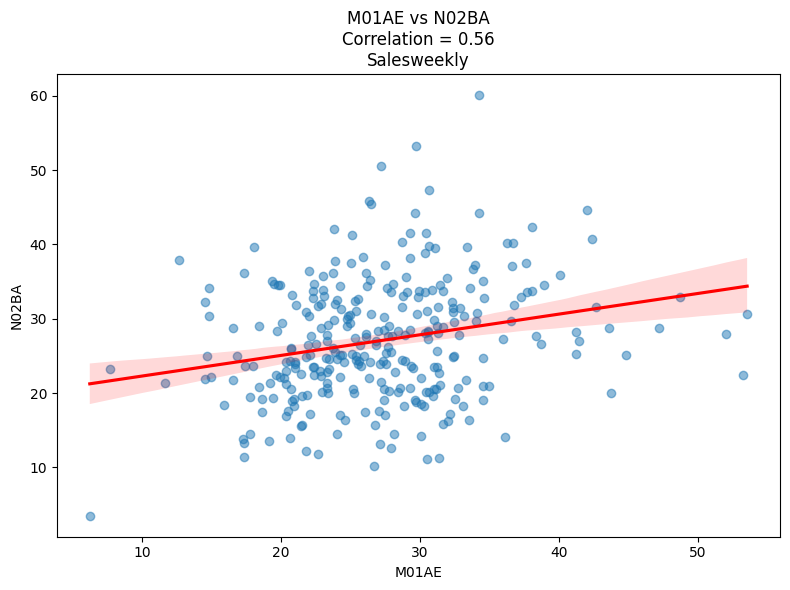

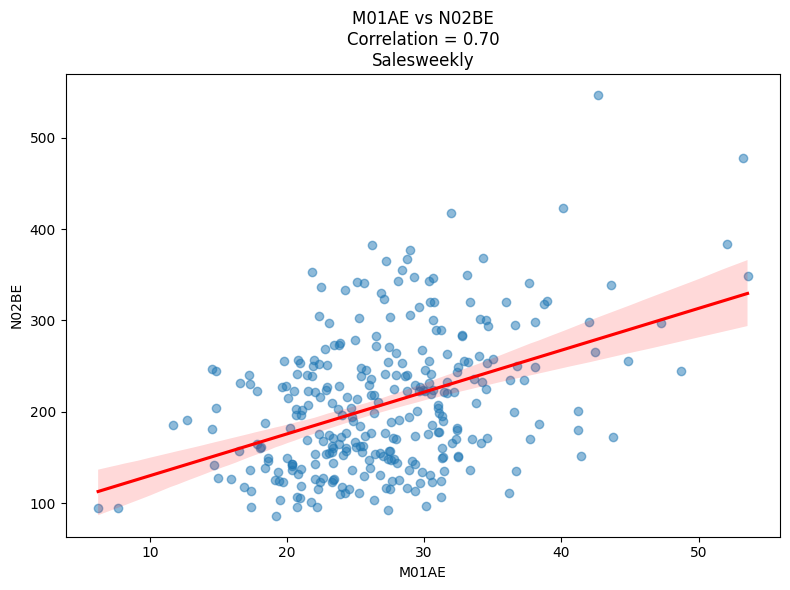

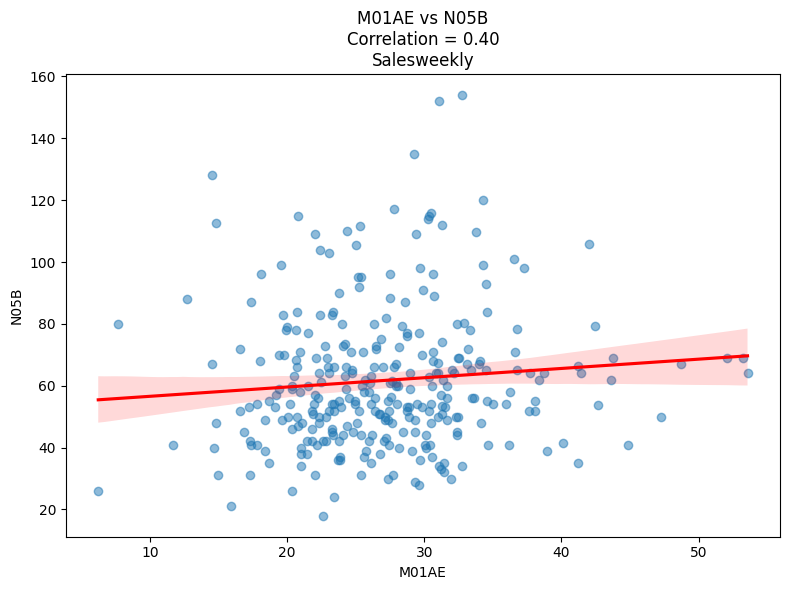

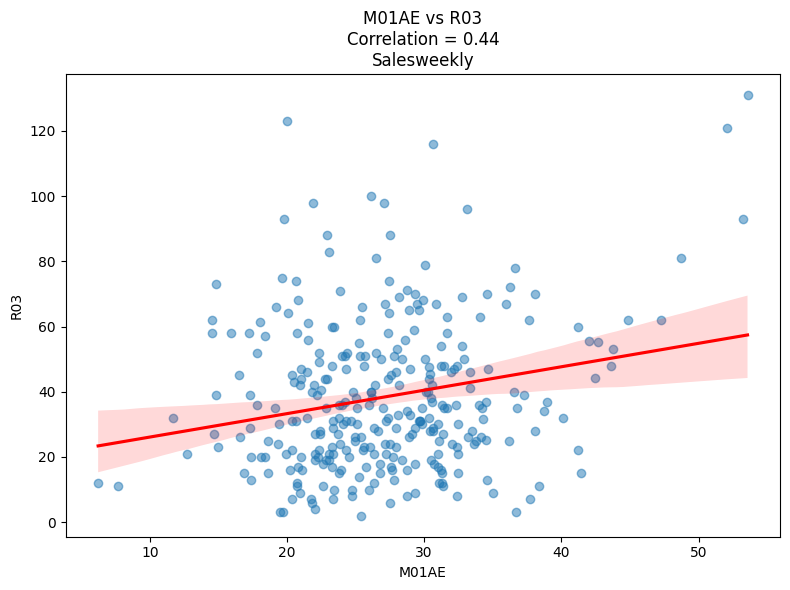

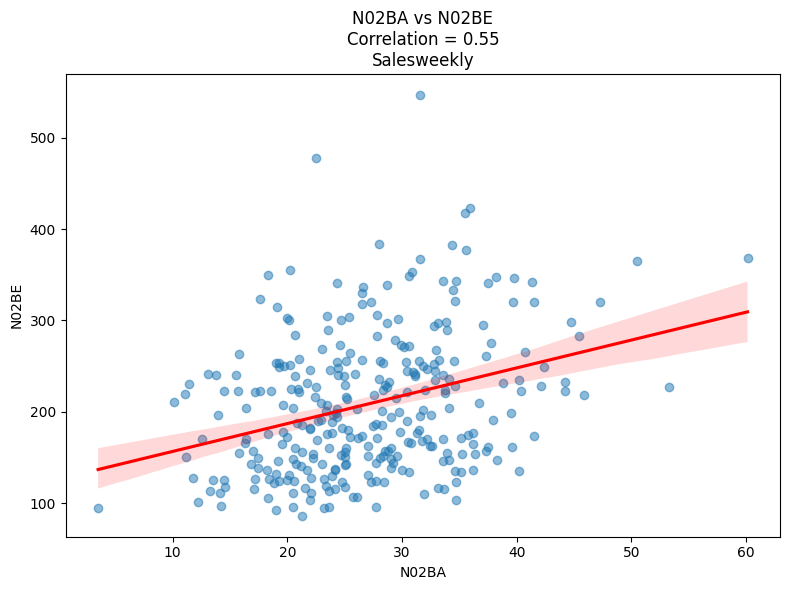

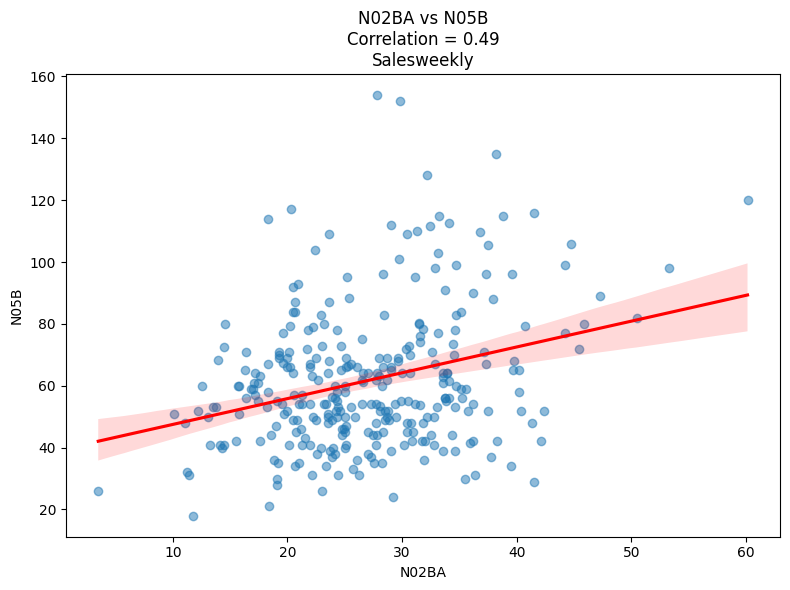

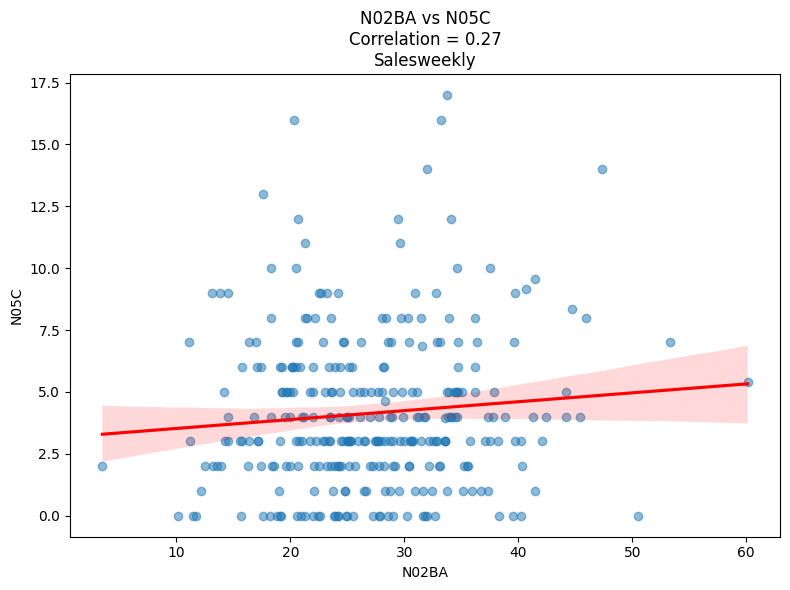

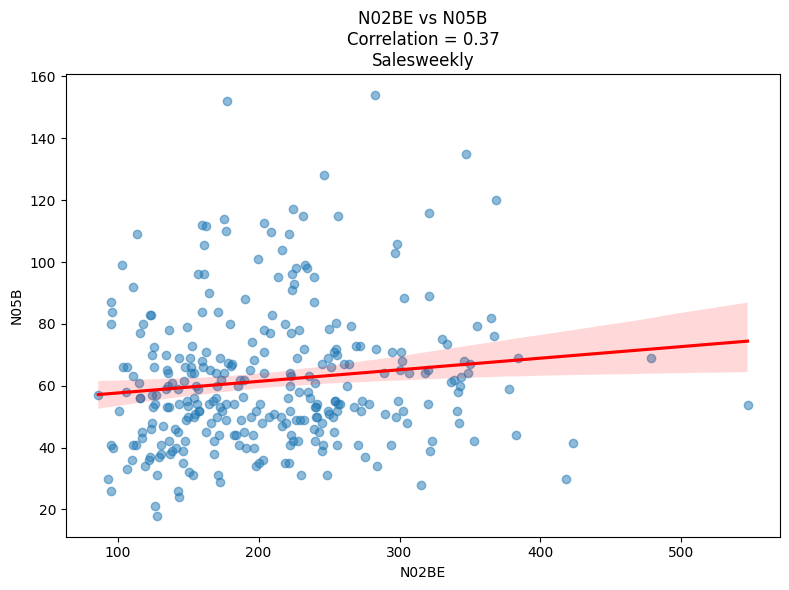

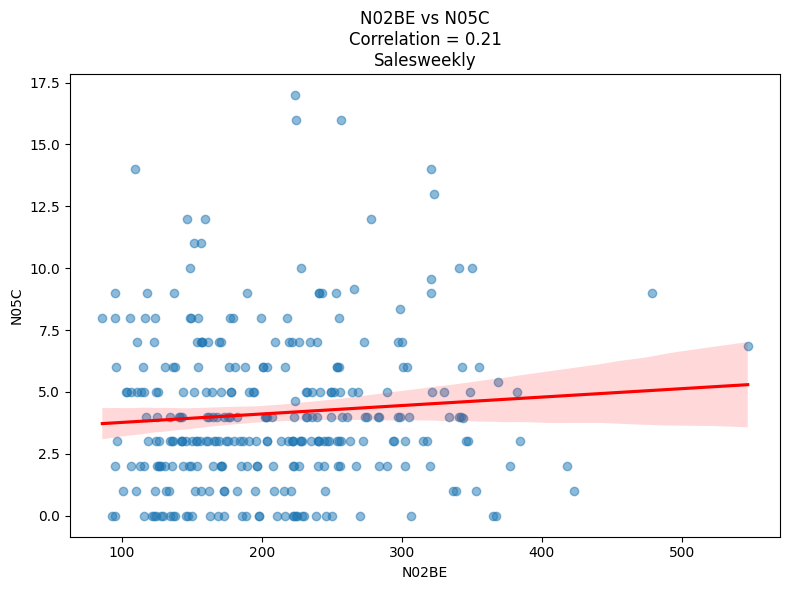

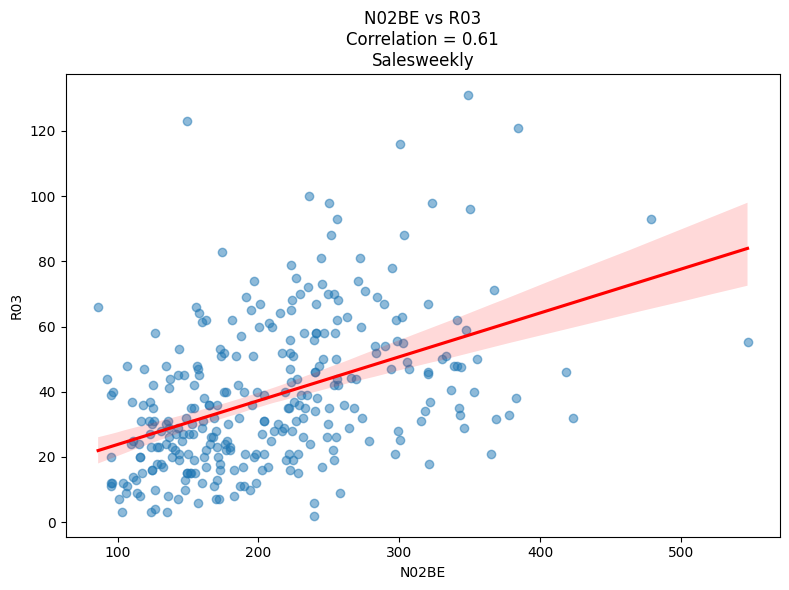

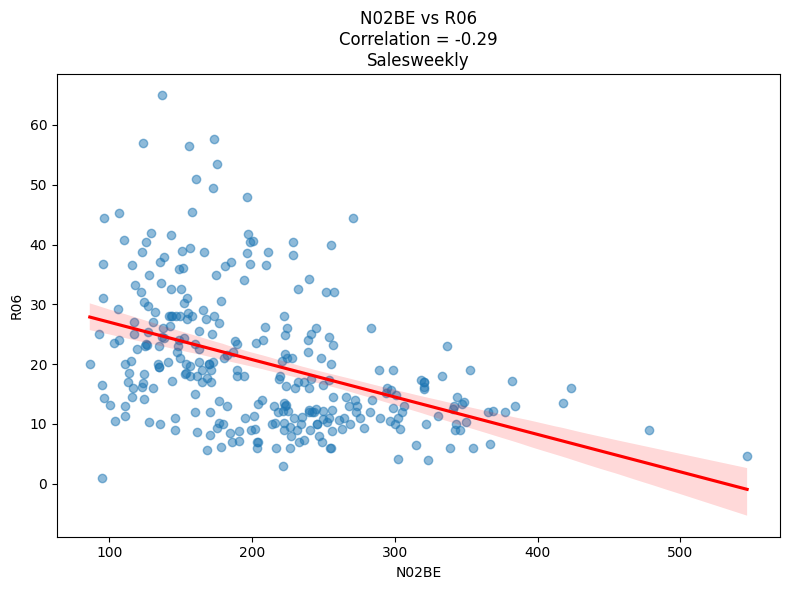

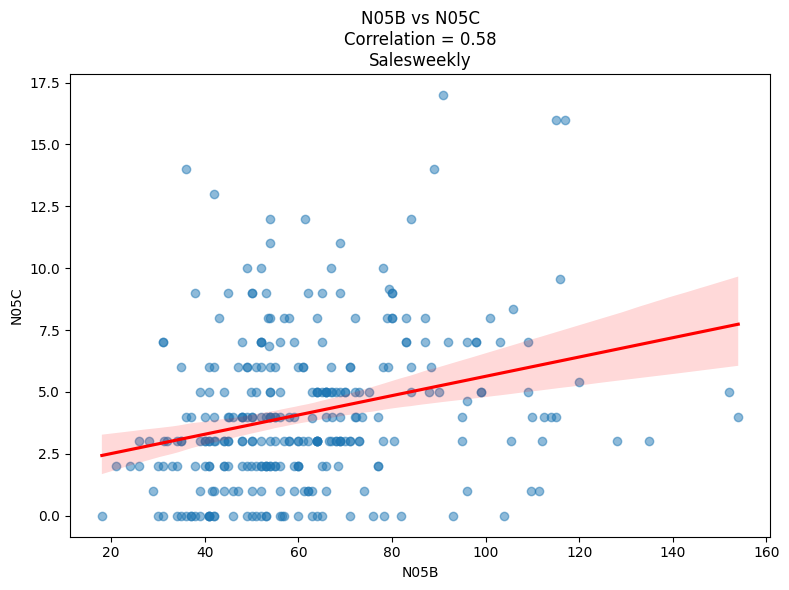

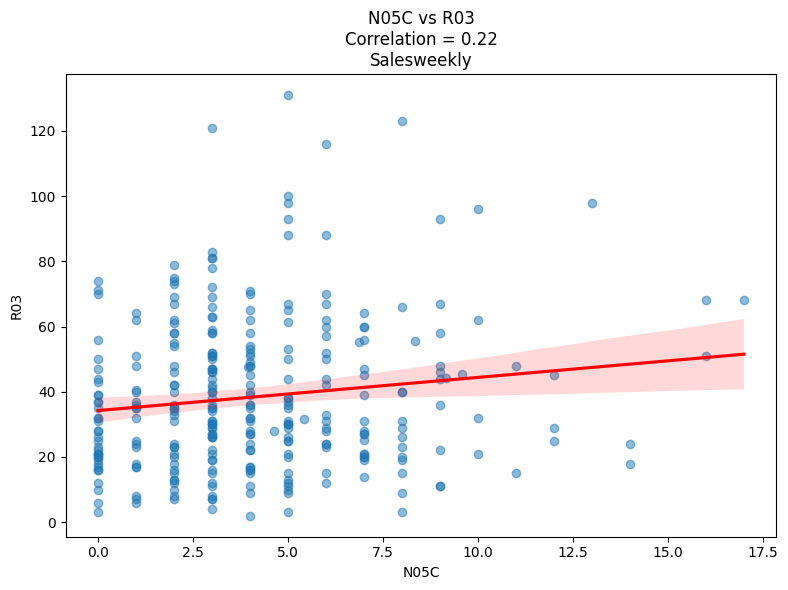

In [26]:
#Lineare Regression för korrelation ab 0.2 bei salesweekly tabelle
for x, y, corr_value in pairs:
    fig, ax = plt.subplots(figsize=(8,6))

    sns.regplot(
        data=df_salesweekly,
        x=x,
        y=y,
        scatter_kws={"alpha":0.5},
        line_kws={"color":"red"},
        ax=ax
    )

    ax.set_title(f"{x} vs {y}\nCorrelation = {corr_value:.2f}\nSalesweekly")

    plt.tight_layout()
    plt.show()